# Recommendation Systems - 2026


#**Intro**:

This notebook tackles a movie rating prediction task using a curated sample of MovieLens 32M. The objective is to predict unseen explicit star ratings (0.5–5.0 in steps of 0.5) from historical user–movie interactions, while taking advantage of an important dataset property: null ratings represent implicit feedback (a user interacted with a movie but did not provide an explicit score). Submissions are evaluated with Weighted RMSE (WRMSE), so very popular movies are slightly down-weighted and do not dominate the loss. Our training loss is aligned with this metric by using a weighted MSE formulation, matching the evaluation objective as closely as possible.

##EDA highlights and modeling implications

The exploratory analysis motivates several key design choices:

* Movie popularity is highly skewed: a small set of movies receives a large fraction of interactions, while most movies are far less frequent. This matches the WRMSE design (down-weight popular movies) and encourages building a model that generalizes beyond blockbusters.

* Implicit interactions are abundant and informative: many user–movie pairs exist without explicit ratings, indicating “watched” behavior that can help learn preferences even when explicit labels are sparse.

* Metadata varies in quality: movies differ in how rich their titles/tags/genres are, and user-provided tags contain duplicates and noise (capitalization differences and minor typos). This motivates careful normalization and a model that can benefit from metadata when available but fallback to priors when weak.

##Preprocessing and feature construction

Before training, we apply preprocessing that improves both robustness and generalization:

* Mapping and indexing: user and movie IDs are mapped to contiguous indices, with index 0 reserved for an UNK (Unknown) row to support cold-start handling.

* Metadata cleaning: movie titles are cleaned (including handling the release year embedded in titles), genres are normalized, and tags are lowercased/cleaned to reduce duplicates caused by casing and minor inconsistencies.

* Tokenization for content features: cleaned title/genres/tags are converted into token sequences per movie. These sequences are used as content inputs, enabling the model to generalize to items with limited interaction history.

##Validation: user-wise holdout

Because the test set is hidden, we estimate performance via an offline split. We use a user-wise holdout strategy (holding out one explicit rating per user for validation) to ensure that validation reflects the true recommendation setting: predicting unseen items for users with history. This prevents overly optimistic evaluation that can occur if the split is not user-aware. In addition to WRMSE, we compute HR@K and NDCG@K on sampled users to assess ranking quality, providing a complementary view beyond pure rating regression.

##Model architecture and regularization

Our final model follows a two-stage design that combines the strengths of implicit-ranking training and explicit-rating regression:

1. Implicit pretraining (BPR stage)
We first train a dot-product model (DotBPRModel) using BPR loss on implicit positives (watched interactions). This stage learns strong user/movie representations from abundant implicit data. Intuitively, BPR encourages the model to rank interacted items above non-interacted items, providing a strong initialization that stabilizes subsequent rating prediction.

2. Rating prediction (NeuMF + content stage)
We then fine-tune a NeuMF-style architecture (NeuMFWithContent) that fuses:

* a GMF branch (generalized matrix factorization; dot-like interactions)

* an MLP branch (nonlinear interactions via multiple layers)

* bias terms (user/item biases)

* content features (movie token sequences derived from title/genres/tags)

This hybrid design captures both linear collaborative structure and more complex user–item interaction patterns, while content inputs support generalization when collaborative signals are sparse.

To reduce overfitting and improve stability, we use standard regularization techniques:

* weight decay (AdamW) to regularize model parameters

* dropout in the MLP branch to improve generalization

* gradient clipping for training stability

* early-best checkpoint selection by validation WRMSE (implicitly, by retaining the best epoch)

* prediction clipping to the valid rating range [0.5,5.0]

##Why ensembling helps (intuition + math)

The final submission uses a 20-seed ensemble (more seeds are likely to help reduce WRMSE, but there's a trade-off with runtime) with validation-weighted averaging. Ensembling helps because neural recommenders are stochastic: different random seeds change initialization, negative sampling, minibatch ordering, and optimization paths, producing models that are individually strong but make partially uncorrelated errors.

From a bias–variance perspective, averaging reduces variance, so as long as covariances are not equal to variances (i.e., models are not identical), variance drops, often translating into lower RMSE/WRMSE. Weighting seeds by validation quality further improves robustness by giving slightly higher influence to models that generalize better on the holdout set.

##Results and outputs

Using this approach (two-stage implicit→explicit training + metadata features + robust preprocessing + validation-guided ensembling), the best leaderboard score achieved is:

* WRMSE = 0.797

* submission file: submission_ensemble_weighted_by_id.csv

##Cold-start strategy (fully addressed at the end of the notebook)

Because the private leaderboard may include unseen users/items, the notebook concludes with a dedicated Cold Start Strategy section. It explains the cold-start problem, implements robust handling for unseen items (and briefly users) using UNK embeddings + content signals, and demonstrates effectiveness via an offline cold-item simulation compared to naive baselines, ensuring the pipeline remains stable even when test data distribution shifts.

#Code:

In [ ]:
# -------------------------
# cell 0: setup and imports
# -------------------------

# import os for path handling
import os

# import re for regex text cleanup
import re

# import math for safe numeric operations
import math

# import time for simple timing prints
import time

# import random for python-level reproducibility
import random

# import zlib for fast deterministic hashing of tokens
import zlib

# import numpy for fast array operations
import numpy as np

# import pandas for eda and preprocessing
import pandas as pd

# import torch for deep learning
import torch

# import torch nn for model layers
import torch.nn as nn

# import torch functional for activations and losses
import torch.nn.functional as F

# import dataset utilities for dataloaders
from torch.utils.data import Dataset, DataLoader

In [ ]:
# -------------------------------
# cell 1: global config and seed
# -------------------------------

# set a global seed for reproducibility
SEED = 42

# set python random seed for reproducibility
random.seed(SEED)

# set numpy random seed for reproducibility
np.random.seed(SEED)

# set torch cpu seed for reproducibility
torch.manual_seed(SEED)

# set torch cuda seed for reproducibility
torch.cuda.manual_seed_all(SEED)

# disable nondeterministic cudnn algorithms for reproducibility
torch.backends.cudnn.deterministic = True

# allow cudnn benchmarking to speed up if determinism is not strict
torch.backends.cudnn.benchmark = False


In [ ]:
# ---------------------------------
# cell 2: file paths (colab inputs)
# ---------------------------------

# set the path to the training set csv
TRAIN_PATH = "/content/train.csv"

# set the path to the movies metadata csv
MOVIES_PATH = "/content/movies.csv"

# set the path to the tags csv
TAGS_PATH = "/content/tags.csv"

# set the path to the sample submission csv
SUBMISSION_SAMPLE_PATH = "/content/ratings_submission.csv"

# set the output path for the final submission csv
SUBMISSION_OUT_PATH = "submission.csv"

In [ ]:
# ---------------------------------------
# cell 3: runtime / training hyperparams
# ---------------------------------------

# set the device to cuda if available
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set a reasonable batch size for rating training on a t4
RATING_BATCH_SIZE = 8192

# set a reasonable batch size for implicit bpr pretraining on a t4
IMPLICIT_BATCH_SIZE = 16384

# set the number of workers for dataloader background loading
NUM_WORKERS = 0

# set pin memory for faster host-to-device copies
PIN_MEMORY = True

# set the maximum number of tokens stored per movie for content features
MAX_TOKENS_PER_MOVIE = 64

# set the hashing vocabulary size for content tokens (bigger can help, but costs memory)
TOKEN_VOCAB_SIZE = 50000

# set the embedding dimension for the content token embeddings
CONTENT_DIM = 64

# set the number of latent factors for gmf and mlp embeddings
LATENT_DIM = 64

# set the mlp hidden layers for neumf
MLP_LAYERS = [256, 128, 64, 32]

# set dropout for the mlp to reduce overfitting
MLP_DROPOUT = 0.2

# set the number of epochs for implicit pretraining
IMPLICIT_PRETRAIN_EPOCHS = 2

# set the number of epochs for rating finetuning
# RATING_FINETUNE_EPOCHS = 4
RATING_FINETUNE_EPOCHS = 3

# set the learning rate for implicit pretraining
IMPLICIT_LR = 3e-3

# set the learning rate for rating finetuning
RATING_LR = 1e-3

# set weight decay to regularize embeddings and mlp weights
WEIGHT_DECAY = 1e-5

# set gradient clipping max norm to stabilize training
GRAD_CLIP_NORM = 5.0

# set the fraction of ranking evaluation samples to keep runtime reasonable
RANK_EVAL_MAX_USERSAMPLES = 5000

# set the number of negatives per positive for ranking evaluation
RANK_EVAL_NEGATIVES = 100

# set the number of negatives per positive during implicit bpr training
BPR_NEGATIVES_PER_POS = 1

# set the auxiliary implicit loss weight during rating finetuning
AUX_IMPLICIT_LOSS_WEIGHT = 0.05

# set the number of implicit pairs to sample per rating batch during finetuning
AUX_IMPLICIT_BATCH_PER_STEP = 4096

# enable mixed precision for faster training on t4
USE_AMP = True


In [ ]:
# -----------------------------------------
# cell 4: helper functions for preprocessing
# -----------------------------------------

# define a fast and robust normalizer for text tokens
def normalize_text(s: str) -> str:
    # handle missing values safely
    if s is None or (isinstance(s, float) and np.isnan(s)):
        # return empty string for missing text
        return ""
    # cast to string to be safe
    s = str(s)
    # lowercase everything to merge case variants
    s = s.lower()
    # replace year patterns in titles like "(1999)" with a space
    s = re.sub(r"\(\s*\d{4}\s*\)", " ", s)
    # replace any non-alphanumeric characters with spaces
    s = re.sub(r"[^a-z0-9]+", " ", s)
    # collapse multiple spaces
    s = re.sub(r"\s+", " ", s)
    # strip leading and trailing spaces
    s = s.strip()
    # return normalized text
    return s


# define a deterministic hashing trick to map tokens to integer ids
def token_to_id(token: str, vocab_size: int) -> int:
    # return 0 for empty tokens (reserved as padding)
    if not token:
        return 0
    # compute a deterministic crc32 hash for speed
    h = zlib.crc32(token.encode("utf-8"))
    # map the hash into [1, vocab_size-1] to keep 0 as padding
    return (h % (vocab_size - 1)) + 1


# define a function to clip predictions to the rating range
def clip_ratings(x: np.ndarray) -> np.ndarray:
    # clip predictions to [0.5, 5.0]
    return np.clip(x, 0.5, 5.0)


# define a function to round predictions to nearest 0.5 increments
def round_to_half(x: np.ndarray) -> np.ndarray:
    # round to nearest 0.5 by scaling then rounding to integer
    return np.round(x * 2.0) / 2.0


# added for cold start safety
# define a helper to make unk (index 0) embeddings/biases meaningful for cold-start
def set_unk_rows_to_mean(model: torch.nn.Module) -> None:
    # disable grad tracking for safe in-place assignment
    with torch.no_grad():
        # collect user indices that appear in training
        u_rows = np.where(user_is_train)[0].astype(np.int64)

        # drop unk=0 from the mean computation
        u_rows = u_rows[u_rows != 0]

        # collect movie indices that appear in training
        m_rows = np.where(movie_is_train)[0].astype(np.int64)

        # drop unk=0 from the mean computation
        m_rows = m_rows[m_rows != 0]

        # if we have at least one seen training user
        if len(u_rows) > 0:
            # move user indices to the correct device
            u_rows_t = torch.from_numpy(u_rows).to(model.user_gmf.weight.device)

            # set unk user gmf embedding to mean of trained users
            model.user_gmf.weight.data[0] = model.user_gmf.weight.data[u_rows_t].mean(dim=0)

            # set unk user mlp embedding to mean of trained users
            model.user_mlp.weight.data[0] = model.user_mlp.weight.data[u_rows_t].mean(dim=0)

            # set unk user bias to mean of trained users
            model.user_bias.weight.data[0] = model.user_bias.weight.data[u_rows_t].mean(dim=0)

        # if we have at least one seen training movie
        if len(m_rows) > 0:
            # move movie indices to the correct device
            m_rows_t = torch.from_numpy(m_rows).to(model.item_gmf.weight.device)

            # set unk item gmf embedding to mean of trained movies
            model.item_gmf.weight.data[0] = model.item_gmf.weight.data[m_rows_t].mean(dim=0)

            # set unk item mlp embedding to mean of trained movies
            model.item_mlp.weight.data[0] = model.item_mlp.weight.data[m_rows_t].mean(dim=0)

            # set unk item bias to mean of trained movies
            model.item_bias.weight.data[0] = model.item_bias.weight.data[m_rows_t].mean(dim=0)



In [ ]:
# -----------------------------------------
# cell 5: load data and run initial eda
# -----------------------------------------

# raise a helpful error if the training file is missing
if not os.path.exists(TRAIN_PATH):
    # fail loudly with instructions
    raise FileNotFoundError(f"missing {TRAIN_PATH}, upload train.csv to this path in colab")

# raise a helpful error if the submission sample file is missing
if not os.path.exists(SUBMISSION_SAMPLE_PATH):
    # fail loudly with instructions
    raise FileNotFoundError(f"missing {SUBMISSION_SAMPLE_PATH}, upload ratings_submission.csv to this path in colab")

# load the train csv with memory-friendly dtypes
train_df = pd.read_csv(
    # provide the file path
    TRAIN_PATH,
    # enforce column dtypes where possible
    dtype={"user_id": "int32", "movie_id": "int32"},
)

# ensure the rating column exists even if pandas inferred differently
if "rating" not in train_df.columns:
    # fail loudly if schema is unexpected
    raise ValueError("train.csv must contain columns: user_id, movie_id, rating")

# load the submission sample csv
sub_df = pd.read_csv(
    # provide the file path
    SUBMISSION_SAMPLE_PATH,
)

# print basic heads for sanity
print("train head:")
print(train_df.head())

# print basic heads for sanity
print("\nsubmission head:")
print(sub_df.head())

# compute explicit vs implicit counts for eda
num_total_rows = len(train_df)

# compute number of implicit rows (null rating)
num_implicit_rows = int(train_df["rating"].isna().sum())

# compute number of explicit rows (non-null rating)
num_explicit_rows = int(num_total_rows - num_implicit_rows)

# print basic dataset size stats
print("\nrows total:", num_total_rows)

# print implicit rows
print("rows implicit (rating is null):", num_implicit_rows)

# print explicit rows
print("rows explicit (rating not null):", num_explicit_rows)

# compute basic rating distribution on explicit data
print("\nexplicit rating describe:")
print(train_df.loc[~train_df["rating"].isna(), "rating"].astype("float32").describe())

# compute number of unique users in training
train_unique_users = int(train_df["user_id"].nunique())

# compute number of unique movies in training
train_unique_movies = int(train_df["movie_id"].nunique())

# print unique users
print("\nunique users in train:", train_unique_users)

# print unique movies
print("unique movies in train:", train_unique_movies)


train head:
   user_id  movie_id  rating
0        0         0     NaN
1        0         8     NaN
2        0        11     NaN
3        0        25     NaN
4        0        31     2.0

submission head:
        id  prediction
0   0_1188           0
1   5_7163           0
2    8_460           0
3   9_3705           0
4  11_2650           0

rows total: 18321319
rows implicit (rating is null): 11017969
rows explicit (rating not null): 7303350

explicit rating describe:
count    7.303350e+06
mean     3.607696e+00
std      1.023767e+00
min      5.000000e-01
25%      3.000000e+00
50%      4.000000e+00
75%      4.500000e+00
max      5.000000e+00
Name: rating, dtype: float64

unique users in train: 100000
unique movies in train: 2000


In [ ]:
# -----------------------------------------------
# cell 6: parse submission ids and cold-start eda
# -----------------------------------------------

# ensure the required id column exists
if "id" not in sub_df.columns:
    # fail loudly if schema is unexpected
    raise ValueError("ratings_submission.csv must contain an 'id' column")

# split id into user_id and movie_id using underscore delimiter
sub_user_movie = sub_df["id"].astype(str).str.split("_", n=1, expand=True)

# name the parsed columns for clarity
sub_user_movie.columns = ["user_id", "movie_id"]

# cast parsed ids to integers
sub_user_movie = sub_user_movie.astype({"user_id": "int32", "movie_id": "int32"})

# compute how many submission users are not in training
cold_users = int(~sub_user_movie["user_id"].isin(train_df["user_id"]).sum())

# compute how many submission movies are not in training
cold_movies = int(~sub_user_movie["movie_id"].isin(train_df["movie_id"]).sum())

# print cold-start stats for submission
print("\nsubmission cold-start users (not in train):", cold_users)

# print cold-start stats for submission
print("submission cold-start movies (not in train):", cold_movies)





submission cold-start users (not in train): -100001
submission cold-start movies (not in train): -100001


In [ ]:
# ------------------------------------------------------
# cell 7: load movies.csv and tags.csv and build content
# ------------------------------------------------------

# load movies metadata if available
if os.path.exists(MOVIES_PATH):
    # read movies csv
    movies_df = pd.read_csv(MOVIES_PATH)
else:
    # create an empty movies df if missing
    movies_df = pd.DataFrame()

# load tags if available
if os.path.exists(TAGS_PATH):
    # read tags csv
    tags_df = pd.read_csv(TAGS_PATH)
else:
    # create an empty tags df if missing
    tags_df = pd.DataFrame()

# print movies schema for eda
print("\nmovies columns:", list(movies_df.columns)[:20])

# print tags schema for eda
print("tags columns:", list(tags_df.columns)[:20])

# try to detect the movie id column name in movies.csv
movie_id_col_movies = "movie_id" if "movie_id" in movies_df.columns else ("movieId" if "movieId" in movies_df.columns else None)

# try to detect the title column name in movies.csv
title_col = "title" if "title" in movies_df.columns else None

# try to detect the genres column name in movies.csv
genres_col = "genres" if "genres" in movies_df.columns else None

# create a mapping of movie_id to title and genres tokens
movie_meta = {}

# build meta only if required columns exist
if movie_id_col_movies is not None:
    # iterate through movies rows to collect title and genres
    for row in movies_df[[movie_id_col_movies] + ([title_col] if title_col else []) + ([genres_col] if genres_col else [])].itertuples(index=False):
        # read movie id from row
        mid = int(getattr(row, movie_id_col_movies))
        # extract title safely
        raw_title = getattr(row, title_col) if title_col else ""
        # extract genres safely
        raw_genres = getattr(row, genres_col) if genres_col else ""
        # normalize title text
        norm_title = normalize_text(raw_title)
        # split title into tokens
        title_tokens = norm_title.split() if norm_title else []
        # normalize genres text
        norm_genres = str(raw_genres).lower() if raw_genres is not None else ""
        # split genres by common delimiter
        genres_tokens = []
        # split by pipe if present
        if "|" in norm_genres:
            # split on pipe
            genres_tokens = [normalize_text(g) for g in norm_genres.split("|")]
        else:
            # split on spaces/commas as fallback
            genres_tokens = [normalize_text(g) for g in re.split(r"[,\s]+", norm_genres)]
        # filter empty tokens
        genres_tokens = [g for g in genres_tokens if g and g != "no genres listed"]
        # store tokens
        movie_meta[mid] = {"title_tokens": title_tokens, "genres_tokens": genres_tokens}

# build tags aggregation only if tags_df has the needed columns
tags_movie_col = "movie_id" if "movie_id" in tags_df.columns else ("movieId" if "movieId" in tags_df.columns else None)

# build tags aggregation only if tags_df has the needed columns
tags_tag_col = "tag" if "tag" in tags_df.columns else None

# set the maximum number of tags tokens to keep per movie (maximal but bounded)
TOP_TAGS_PER_MOVIE = 32

# create movie -> list of top tags tokens
movie_top_tags = {}

# aggregate tags if possible
if tags_movie_col is not None and tags_tag_col is not None and len(tags_df) > 0:
    # normalize tags into a new column
    tags_df["tag_norm"] = tags_df[tags_tag_col].map(normalize_text)
    # drop empty normalized tags
    tags_df = tags_df.loc[tags_df["tag_norm"] != ""].copy()
    # count (movie, tag) frequency
    tag_counts = tags_df.groupby([tags_movie_col, "tag_norm"], sort=False).size().reset_index(name="cnt")
    # sort by movie then count descending
    tag_counts = tag_counts.sort_values([tags_movie_col, "cnt"], ascending=[True, False])
    # take top tags per movie
    tag_counts = tag_counts.groupby(tags_movie_col, sort=False).head(TOP_TAGS_PER_MOVIE)
    # build the dictionary
    for mid, grp in tag_counts.groupby(tags_movie_col, sort=False):
        # store tag tokens as single-token tags (already normalized)
        movie_top_tags[int(mid)] = grp["tag_norm"].tolist()

# define a function to combine all tokens for a movie id
def build_movie_tokens(mid: int) -> list:
    # create an empty token list
    tokens = []
    # add genres tokens if available
    if mid in movie_meta:
        # extend with genres tokens
        tokens.extend(movie_meta[mid].get("genres_tokens", []))
        # extend with title tokens
        tokens.extend(movie_meta[mid].get("title_tokens", []))
    # add top tag tokens if available
    if mid in movie_top_tags:
        # extend tokens with tags
        tokens.extend(movie_top_tags[mid])
    # filter empty tokens again
    tokens = [t for t in tokens if t]
    # return tokens
    return tokens



movies columns: ['movie_id', 'title', 'genres']
tags columns: ['user_id', 'movie_id', 'tag']



eda summary:
                       metric         value
0                  total rows  1.832132e+07
1               explicit rows  7.303350e+06
2               implicit rows  1.101797e+07
3           implicit fraction  6.013742e-01
4          unique users (all)  1.000000e+05
5         unique movies (all)  2.000000e+03
6     unique users (explicit)  1.000000e+05
7    unique movies (explicit)  2.000000e+03
8  explicit sparsity (approx)  3.651675e-02

unique explicit ratings (sample): [0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]

explicit rating counts:
rating
0.5      96296
1.0     178994
1.5     105808
2.0     419411
2.5     353890
3.0    1327810
3.5     987576
4.0    2001570
4.5     734713
5.0    1097282
Name: count, dtype: int64


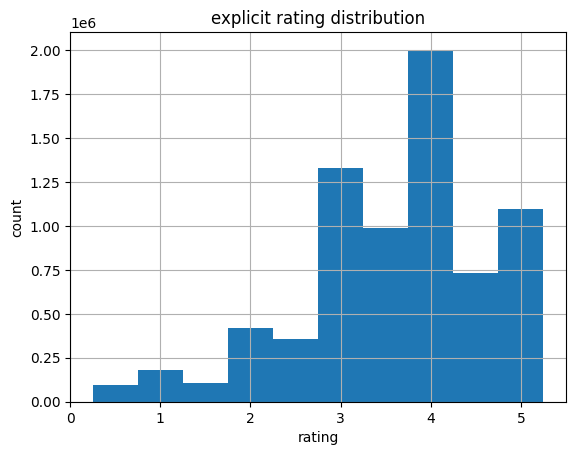


movie explicit count describe:
count     2000.000000
mean      3651.675000
std       3340.914196
min        820.000000
25%       1563.750000
50%       2430.000000
75%       4361.250000
max      25884.000000
dtype: float64

user explicit count describe:
count    100000.000000
mean         73.033500
std          69.344917
min          20.000000
25%          30.000000
50%          48.000000
75%          88.000000
max         806.000000
dtype: float64

movie total interaction count describe:
count     2000.000000
mean      9160.659500
std       8375.822766
min       2097.000000
25%       3943.000000
50%       6117.500000
75%      10953.000000
max      65115.000000
dtype: float64

user total interaction count describe:
count    100000.000000
mean        183.213190
std         173.312738
min          26.000000
25%          76.000000
50%         120.000000
75%         221.000000
max        1996.000000
dtype: float64


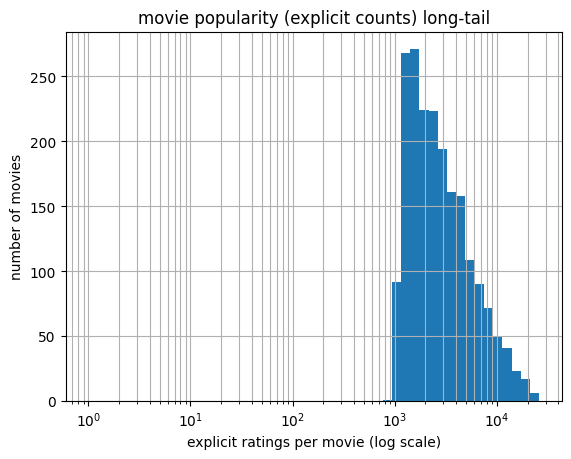

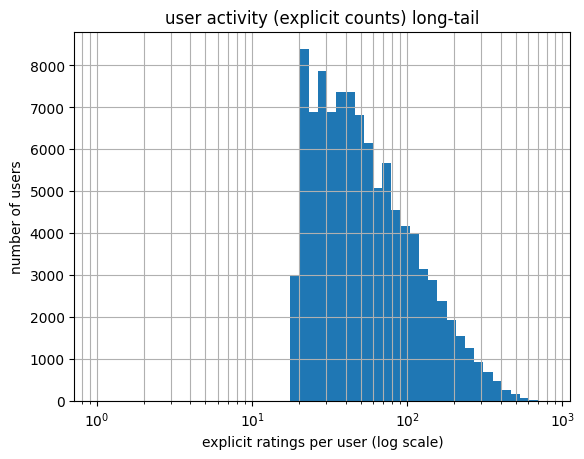

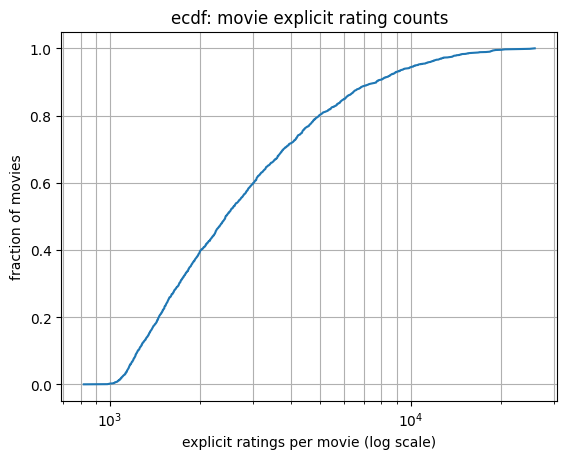


top 20 movies by explicit rating count:
          count  mean_rating
movie_id                    
366       25884     4.024726
290       25423     4.196908
308       25245     4.391780
2561      24916     4.151609
603       23533     4.130094
270       22627     4.107460
2949      20622     4.219062
1190      20347     4.139578
490       20237     3.697238
5003      19991     4.080286
517       19194     4.218401
583       19167     3.969244
1188      18953     4.119638
100       18782     3.954424
5962      18698     4.066504
1200      18685     3.988253
11        18588     3.884845
1276      18525     3.962375
7163      18433     4.087343
56        18423     4.258074


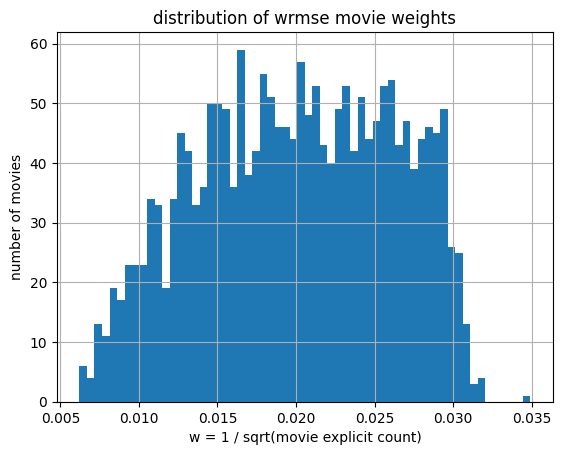


submission overlap check:
submission users: 100000  | cold users: 0
submission movies: 2000  | cold movies: 0


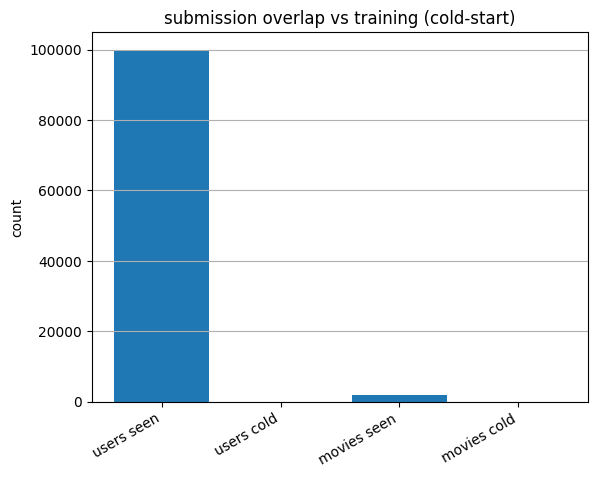


movies.csv coverage:
train movies covered: 2000 / 2000
submission movies covered: 2000 / 2000


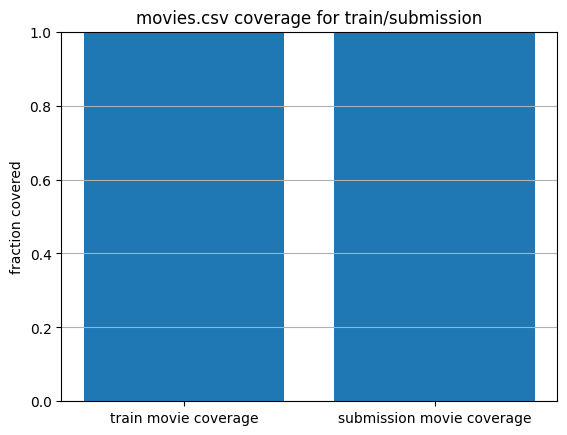


tags.csv coverage:
train movies with any tag: 2000 / 2000
submission movies with any tag: 2000 / 2000


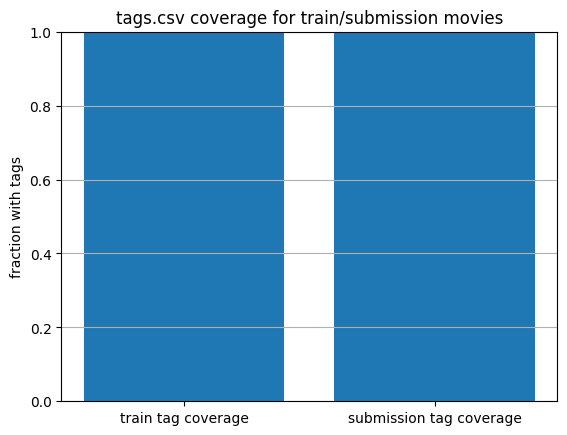


top 50 normalized tags:
tag_norm
sci fi                     9960
atmospheric                7682
action                     7285
comedy                     6405
visually appealing         5967
funny                      5718
thought provoking          5561
twist ending               5424
surreal                    5366
dark comedy                4782
dystopia                   4732
classic                    4378
based on a book            4133
psychology                 4083
stylized                   4080
fantasy                    4006
adventure                  3919
quirky                     3918
dark                       3899
social commentary          3864
cinematography             3606
romance                    3590
time travel                3435
superhero                  3362
thriller                   3358
great soundtrack           3327
space                      3252
psychological              3176
violence                   2982
suspense                   2981
black 

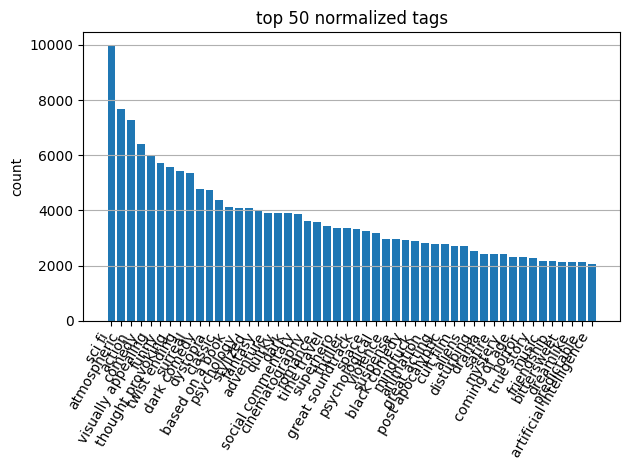


top 20 genres:
genres
drama          879
comedy         729
action         622
thriller       555
adventure      465
romance        365
sci fi         362
crime          314
fantasy        228
children       174
mystery        170
horror         148
animation      143
imax            93
war             91
musical         78
western         40
film noir       21
documentary     12
Name: count, dtype: int64


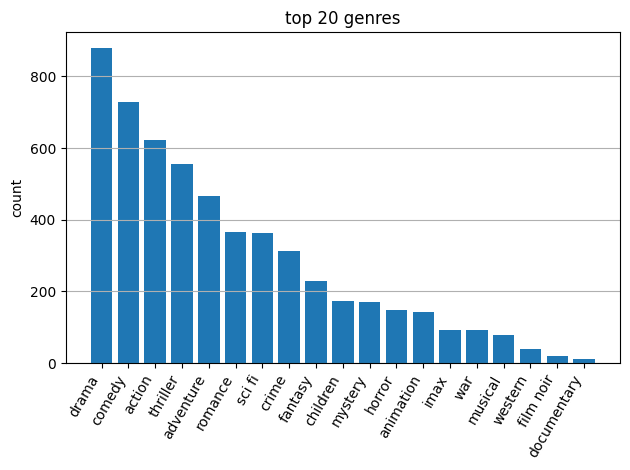


share of titles with trailing (year): 0.999


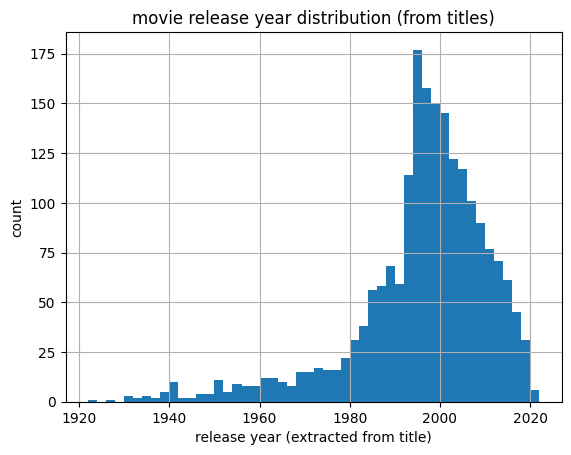


skipping token coverage eda because movie2idx/movie_token_lens are not built yet (run after mapping cells).


In [ ]:
# ===============================
# eda expansion
# ===============================

# -------------------------
# cell eda-0: imports for charts
# -------------------------

# import matplotlib for plotting
import matplotlib.pyplot as plt

# import matplotlib ticker for nicer axes formatting
import matplotlib.ticker as mticker


# -----------------------------------------
# cell eda-1: basic dataset summary table
# -----------------------------------------

# compute total row count
total_rows = int(len(train_df))

# compute implicit row count
implicit_rows = int(train_df["rating"].isna().sum())

# compute explicit row count
explicit_rows = int(total_rows - implicit_rows)

# compute unique users in all rows
n_users_all = int(train_df["user_id"].nunique())

# compute unique movies in all rows
n_movies_all = int(train_df["movie_id"].nunique())

# compute unique users in explicit rows
n_users_explicit = int(train_df.loc[~train_df["rating"].isna(), "user_id"].nunique())

# compute unique movies in explicit rows
n_movies_explicit = int(train_df.loc[~train_df["rating"].isna(), "movie_id"].nunique())

# compute explicit sparsity estimate (explicit interactions over full user-item grid)
explicit_sparsity = float(explicit_rows / max(1.0, float(n_users_all) * float(n_movies_all)))

# compute implicit fraction
implicit_frac = float(implicit_rows / max(1, total_rows))

# build a summary dataframe
summary_df = pd.DataFrame(
    # set key metrics
    {
        "metric": [
            "total rows",
            "explicit rows",
            "implicit rows",
            "implicit fraction",
            "unique users (all)",
            "unique movies (all)",
            "unique users (explicit)",
            "unique movies (explicit)",
            "explicit sparsity (approx)",
        ],
        "value": [
            total_rows,
            explicit_rows,
            implicit_rows,
            implicit_frac,
            n_users_all,
            n_movies_all,
            n_users_explicit,
            n_movies_explicit,
            explicit_sparsity,
        ],
    }
)

# print the summary
print("\neda summary:")
print(summary_df)


# ---------------------------------------------------------
# cell eda-2: rating distribution (explicit) + chart
# ---------------------------------------------------------

# extract explicit ratings as float32
explicit_ratings = train_df.loc[~train_df["rating"].isna(), "rating"].astype("float32")

# print unique rating values to confirm 0.5 increments
print("\nunique explicit ratings (sample):", np.sort(explicit_ratings.unique())[:20])

# compute rating counts
rating_counts = explicit_ratings.value_counts().sort_index()

# print rating counts
print("\nexplicit rating counts:")
print(rating_counts)

# create a figure for rating histogram
plt.figure()

# plot rating histogram using exact bins
plt.hist(explicit_ratings.to_numpy(), bins=np.arange(0.25, 5.26, 0.5))

# set x label
plt.xlabel("rating")

# set y label
plt.ylabel("count")

# set title
plt.title("explicit rating distribution")

# show grid
plt.grid(True)

# show the plot
plt.show()


# -------------------------------------------------------------------
# cell eda-3: user/movie activity distributions (explicit vs all)
# -------------------------------------------------------------------

# compute explicit counts per movie
movie_exp_counts = train_df.loc[~train_df["rating"].isna()].groupby("movie_id").size().astype("int32")

# compute explicit counts per user
user_exp_counts = train_df.loc[~train_df["rating"].isna()].groupby("user_id").size().astype("int32")

# compute total interaction counts per movie (explicit + implicit)
movie_all_counts = train_df.groupby("movie_id").size().astype("int32")

# compute total interaction counts per user (explicit + implicit)
user_all_counts = train_df.groupby("user_id").size().astype("int32")

# print descriptive stats for movie explicit counts
print("\nmovie explicit count describe:")
print(movie_exp_counts.describe())

# print descriptive stats for user explicit counts
print("\nuser explicit count describe:")
print(user_exp_counts.describe())

# print descriptive stats for movie total counts
print("\nmovie total interaction count describe:")
print(movie_all_counts.describe())

# print descriptive stats for user total counts
print("\nuser total interaction count describe:")
print(user_all_counts.describe())


# ---------------------------------------------------------
# cell eda-4: movie long-tail chart (explicit counts)
# ---------------------------------------------------------

# create a figure for movie count histogram
plt.figure()

# build log-spaced bins for long-tail visibility
movie_bins = np.logspace(0, np.log10(max(1, int(movie_exp_counts.max()))), 50)

# plot histogram with log bins
plt.hist(movie_exp_counts.to_numpy(), bins=movie_bins)

# set x scale to log
plt.xscale("log")

# set x label
plt.xlabel("explicit ratings per movie (log scale)")

# set y label
plt.ylabel("number of movies")

# set title
plt.title("movie popularity (explicit counts) long-tail")

# show grid
plt.grid(True, which="both")

# show the plot
plt.show()


# ---------------------------------------------------------
# cell eda-5: user activity chart (explicit counts)
# ---------------------------------------------------------

# create a figure for user count histogram
plt.figure()

# build log-spaced bins for long-tail visibility
user_bins = np.logspace(0, np.log10(max(1, int(user_exp_counts.max()))), 50)

# plot histogram with log bins
plt.hist(user_exp_counts.to_numpy(), bins=user_bins)

# set x scale to log
plt.xscale("log")

# set x label
plt.xlabel("explicit ratings per user (log scale)")

# set y label
plt.ylabel("number of users")

# set title
plt.title("user activity (explicit counts) long-tail")

# show grid
plt.grid(True, which="both")

# show the plot
plt.show()


# ---------------------------------------------------------
# cell eda-6: ecdf of movie popularity (explicit)
# ---------------------------------------------------------

# sort movie counts
sorted_movie_counts = np.sort(movie_exp_counts.to_numpy())

# build ecdf y values
ecdf_y = np.arange(1, len(sorted_movie_counts) + 1) / float(len(sorted_movie_counts))

# create a figure for ecdf
plt.figure()

# plot ecdf
plt.plot(sorted_movie_counts, ecdf_y)

# set x scale to log
plt.xscale("log")

# set x label
plt.xlabel("explicit ratings per movie (log scale)")

# set y label
plt.ylabel("fraction of movies")

# set title
plt.title("ecdf: movie explicit rating counts")

# show grid
plt.grid(True, which="both")

# show the plot
plt.show()


# ---------------------------------------------------------
# cell eda-7: top movies by explicit count + mean rating
# ---------------------------------------------------------

# compute mean rating per movie (explicit only)
movie_mean_rating = train_df.loc[~train_df["rating"].isna()].groupby("movie_id")["rating"].mean().astype("float32")

# create a dataframe for movie stats
movie_stats = pd.DataFrame(
    # build stats columns
    {"count": movie_exp_counts, "mean_rating": movie_mean_rating}
)

# sort by count descending
movie_stats_top = movie_stats.sort_values("count", ascending=False).head(20)

# print top movies stats
print("\ntop 20 movies by explicit rating count:")
print(movie_stats_top)


# ---------------------------------------------------------
# cell eda-8: wrmse weight distribution chart
# ---------------------------------------------------------

# compute weights from explicit counts (full train explicit, not split)
full_movie_exp_counts = train_df.loc[~train_df["rating"].isna()].groupby("movie_id").size().astype("float32")

# compute weights as 1/sqrt(count)
full_movie_weights = (1.0 / np.sqrt(full_movie_exp_counts)).astype("float32")

# create a figure for weight histogram
plt.figure()

# plot weight histogram
plt.hist(full_movie_weights.to_numpy(), bins=60)

# set x label
plt.xlabel("w = 1 / sqrt(movie explicit count)")

# set y label
plt.ylabel("number of movies")

# set title
plt.title("distribution of wrmse movie weights")

# show grid
plt.grid(True)

# show the plot
plt.show()


# ---------------------------------------------------------
# cell eda-9: submission overlap and cold-start diagnostics
# ---------------------------------------------------------

# build submission user set
sub_user_set = set(sub_user_movie["user_id"].astype("int64").tolist())

# build submission movie set
sub_movie_set = set(sub_user_movie["movie_id"].astype("int64").tolist())

# build training user set
train_user_set = set(train_df["user_id"].astype("int64").unique().tolist())

# build training movie set
train_movie_set = set(train_df["movie_id"].astype("int64").unique().tolist())

# compute cold users
cold_user_ids = list(sub_user_set - train_user_set)

# compute cold movies
cold_movie_ids = list(sub_movie_set - train_movie_set)

# print counts
print("\nsubmission overlap check:")
print("submission users:", len(sub_user_set), " | cold users:", len(cold_user_ids))
print("submission movies:", len(sub_movie_set), " | cold movies:", len(cold_movie_ids))

# build overlap numbers for plotting
overlap_vals = [
    len(sub_user_set) - len(cold_user_ids),
    len(cold_user_ids),
    len(sub_movie_set) - len(cold_movie_ids),
    len(cold_movie_ids),
]

# build overlap labels
overlap_labels = [
    "users seen",
    "users cold",
    "movies seen",
    "movies cold",
]

# create a figure
plt.figure()

# plot bar chart
plt.bar(overlap_labels, overlap_vals)

# set y label
plt.ylabel("count")

# set title
plt.title("submission overlap vs training (cold-start)")

# rotate x labels
plt.xticks(rotation=30, ha="right")

# show grid
plt.grid(True, axis="y")

# show plot
plt.show()


# ---------------------------------------------------------
# cell eda-10: metadata coverage (movies.csv)
# ---------------------------------------------------------

# detect movie id column in movies.csv
movies_mid_col = "movie_id" if "movie_id" in movies_df.columns else ("movieId" if "movieId" in movies_df.columns else None)

# build movies.csv id set
movies_meta_set = set(movies_df[movies_mid_col].astype("int64").unique().tolist()) if movies_mid_col else set()

# compute training movie coverage in movies.csv
train_movies_in_meta = int(len(train_movie_set & movies_meta_set))

# compute submission movie coverage in movies.csv
sub_movies_in_meta = int(len(sub_movie_set & movies_meta_set))

# print coverage stats
print("\nmovies.csv coverage:")
print("train movies covered:", train_movies_in_meta, "/", len(train_movie_set))
print("submission movies covered:", sub_movies_in_meta, "/", len(sub_movie_set))

# compute coverage fractions
meta_cov_vals = [
    train_movies_in_meta / max(1, len(train_movie_set)),
    sub_movies_in_meta / max(1, len(sub_movie_set)),
]

# create figure
plt.figure()

# plot coverage bars
plt.bar(["train movie coverage", "submission movie coverage"], meta_cov_vals)

# set y label
plt.ylabel("fraction covered")

# set title
plt.title("movies.csv coverage for train/submission")

# set y limits
plt.ylim(0.0, 1.0)

# show grid
plt.grid(True, axis="y")

# show plot
plt.show()


# ---------------------------------------------------------
# cell eda-11: tags coverage + top tags (normalized)
# ---------------------------------------------------------

# detect movie id column in tags.csv
tags_mid_col = "movie_id" if "movie_id" in tags_df.columns else ("movieId" if "movieId" in tags_df.columns else None)

# detect tag text column in tags.csv
tags_tag_col = "tag" if "tag" in tags_df.columns else None

# compute tags movie coverage set
tags_movie_set = set(tags_df[tags_mid_col].astype("int64").unique().tolist()) if tags_mid_col else set()

# compute training movie coverage in tags.csv
train_movies_in_tags = int(len(train_movie_set & tags_movie_set))

# compute submission movie coverage in tags.csv
sub_movies_in_tags = int(len(sub_movie_set & tags_movie_set))

# print tags coverage stats
print("\ntags.csv coverage:")
print("train movies with any tag:", train_movies_in_tags, "/", len(train_movie_set))
print("submission movies with any tag:", sub_movies_in_tags, "/", len(sub_movie_set))

# build tags coverage fractions
tags_cov_vals = [
    train_movies_in_tags / max(1, len(train_movie_set)),
    sub_movies_in_tags / max(1, len(sub_movie_set)),
]

# create figure
plt.figure()

# plot coverage bars
plt.bar(["train tag coverage", "submission tag coverage"], tags_cov_vals)

# set y label
plt.ylabel("fraction with tags")

# set title
plt.title("tags.csv coverage for train/submission movies")

# set y limits
plt.ylim(0.0, 1.0)

# show grid
plt.grid(True, axis="y")

# show plot
plt.show()

# proceed only if tag columns exist
if tags_mid_col is not None and tags_tag_col is not None and len(tags_df) > 0:
    # create normalized tag column
    tags_df["tag_norm"] = tags_df[tags_tag_col].map(normalize_text)
    # filter empty tags
    tags_df_nonempty = tags_df.loc[tags_df["tag_norm"] != ""].copy()
    # compute top tags
    top_tags = tags_df_nonempty["tag_norm"].value_counts().head(50)
    # try head(50)
    # print top tags
    print("\ntop 50 normalized tags:")
    print(top_tags)
    # create figure for tags bar chart
    plt.figure()
    # plot top tags counts
    plt.bar(range(len(top_tags)), top_tags.to_numpy())
    # set x ticks to tag strings
    plt.xticks(range(len(top_tags)), top_tags.index.tolist(), rotation=60, ha="right")
    # set y label
    plt.ylabel("count")
    # set title
    plt.title("top 50 normalized tags")
    # show grid
    plt.grid(True, axis="y")
    # tighten layout to fit labels
    plt.tight_layout()
    # show plot
    plt.show()


# ---------------------------------------------------------
# cell eda-12: genres analysis (normalized) + chart
# ---------------------------------------------------------

# detect genres column name
movies_genres_col = "genres" if "genres" in movies_df.columns else None

# proceed only if genres exist
if movies_mid_col is not None and movies_genres_col is not None and len(movies_df) > 0:
    # extract genres column as string
    genres_series = movies_df[movies_genres_col].astype(str)
    # split genres by pipe into lists
    genres_lists = genres_series.str.lower().str.split("|")
    # explode into rows
    genres_exploded = genres_lists.explode()
    # normalize each genre token
    genres_norm = genres_exploded.map(lambda x: normalize_text(x))
    # filter empty and common placeholder
    genres_norm = genres_norm.loc[(genres_norm != "") & (genres_norm != "no genres listed")]
    # count genres
    top_genres = genres_norm.value_counts().head(20)
    # print top genres
    print("\ntop 20 genres:")
    print(top_genres)
    # create figure
    plt.figure()
    # plot top genres counts
    plt.bar(range(len(top_genres)), top_genres.to_numpy())
    # set xticks to genre names
    plt.xticks(range(len(top_genres)), top_genres.index.tolist(), rotation=60, ha="right")
    # set y label
    plt.ylabel("count")
    # set title
    plt.title("top 20 genres")
    # show grid
    plt.grid(True, axis="y")
    # tighten layout
    plt.tight_layout()
    # show plot
    plt.show()


# ---------------------------------------------------------
# cell eda-13: title year extraction coverage (if titles exist)
# ---------------------------------------------------------

# detect title column
movies_title_col = "title" if "title" in movies_df.columns else None

# proceed only if titles exist
if movies_mid_col is not None and movies_title_col is not None and len(movies_df) > 0:
    # extract raw titles
    titles_raw = movies_df[movies_title_col].astype(str)
    # extract year pattern at end
    years = titles_raw.str.extract(r"\((\d{4})\)\s*$")[0]
    # compute year coverage
    year_cov = float(years.notna().mean())
    # print year coverage
    print("\nshare of titles with trailing (year):", year_cov)
    # build year numeric series
    years_num = pd.to_numeric(years, errors="coerce")
    # drop missing years
    years_num = years_num.dropna()
    # plot year histogram if enough values
    if len(years_num) > 0:
        # create figure
        plt.figure()
        # plot histogram
        plt.hist(years_num.to_numpy(), bins=50)
        # set x label
        plt.xlabel("release year (extracted from title)")
        # set y label
        plt.ylabel("count")
        # set title
        plt.title("movie release year distribution (from titles)")
        # show grid
        plt.grid(True)
        # show plot
        plt.show()


# ---------------------------------------------------------
# cell eda-14: content token coverage and length distribution
# ---------------------------------------------------------

# build a movie list for which we will compute token lengths (train + submission movies)
movies_for_tokens = np.array(sorted(list(train_movie_set | sub_movie_set)), dtype=np.int64)

# map to indices using movie2idx if available (if you run after mapping cell, this exists)
if "movie2idx" in globals():
    # map movie ids to indices
    movies_for_tokens_idx = np.array([movie2idx.get(int(mid), 0) for mid in movies_for_tokens], dtype=np.int32)
    # gather token lengths
    token_lens_sel = movie_token_lens[movies_for_tokens_idx]
    # compute coverage fraction
    token_cov = float(np.mean(token_lens_sel > 0))
    # print token coverage
    print("\ncontent token coverage over train+submission movies:", token_cov)
    # plot token length distribution
    plt.figure()
    # plot histogram of lengths
    plt.hist(token_lens_sel, bins=range(0, MAX_TOKENS_PER_MOVIE + 2))
    # set x label
    plt.xlabel("number of content tokens per movie (capped)")
    # set y label
    plt.ylabel("number of movies")
    # set title
    plt.title("content token length distribution")
    # show grid
    plt.grid(True)
    # show plot
    plt.show()
else:
    # print a note if mapping isn't built yet
    print("\nskipping token coverage eda because movie2idx/movie_token_lens are not built yet (run after mapping cells).")


In [ ]:
# ---------------------------------------------------------
# cell 8: build id mappings with unk support for cold-start
# ---------------------------------------------------------

# collect all user ids from training
train_user_ids = train_df["user_id"].unique()

# collect all movie ids from training
train_movie_ids = train_df["movie_id"].unique()

# collect all user ids from submission
sub_user_ids = sub_user_movie["user_id"].unique()

# collect all movie ids from submission
sub_movie_ids = sub_user_movie["movie_id"].unique()

# build the union of user ids (train + submission) for robust inference
all_user_ids = np.unique(np.concatenate([train_user_ids, sub_user_ids]))

# build the union of movie ids (train + submission) for robust inference
all_movie_ids = np.unique(np.concatenate([train_movie_ids, sub_movie_ids]))

# sort user ids for stable mapping
all_user_ids = np.sort(all_user_ids)

# sort movie ids for stable mapping
all_movie_ids = np.sort(all_movie_ids)

# create user id to index mapping with 0 reserved for unk
user2idx = {int(uid): int(i + 1) for i, uid in enumerate(all_user_ids)}

# create movie id to index mapping with 0 reserved for unk
movie2idx = {int(mid): int(i + 1) for i, mid in enumerate(all_movie_ids)}

# compute the number of users including unk
num_users = int(len(user2idx) + 1)

# compute the number of movies including unk
num_movies = int(len(movie2idx) + 1)

# print mapping sizes
print("\nnum users (with unk):", num_users)

# print mapping sizes
print("num movies (with unk):", num_movies)

# added after initial training for cold start safety
# build boolean arrays that mark which embedding indices are seen in training
user_is_train = np.zeros((num_users,), dtype=np.bool_)

# build boolean arrays that mark which embedding indices are seen in training
movie_is_train = np.zeros((num_movies,), dtype=np.bool_)

# mark all users that appear in the training data
for uid in train_user_ids:
    # map raw user id to embedding index
    user_is_train[user2idx[int(uid)]] = True

# mark all movies that appear in the training data
for mid in train_movie_ids:
    # map raw movie id to embedding index
    movie_is_train[movie2idx[int(mid)]] = True




num users (with unk): 100001
num movies (with unk): 2001


In [ ]:
# -------------------------------------------------------------------
# cell 9: build per-movie token matrix for fast batched content lookup
# -------------------------------------------------------------------

# allocate a token id matrix for movies with padding index 0
movie_token_ids = np.zeros((num_movies, MAX_TOKENS_PER_MOVIE), dtype=np.int32)

# allocate a token length vector for movies
movie_token_lens = np.zeros((num_movies,), dtype=np.int32)


# build tokens for each movie id in the mapping
for mid, midx in movie2idx.items():
    # build combined tokens for this movie id
    tokens = build_movie_tokens(mid)
    # map tokens to hashed ids
    token_ids = [token_to_id(t, TOKEN_VOCAB_SIZE) for t in tokens]
    # deduplicate while keeping order to reduce noise
    seen = set()
    # create ordered unique list
    token_ids_unique = []
    # loop token ids
    for tid in token_ids:
        # skip padding
        if tid == 0:
            # continue to next
            continue
        # check if already seen
        if tid in seen:
            # skip duplicates
            continue
        # add to seen
        seen.add(tid)
        # append unique token id
        token_ids_unique.append(tid)
    # cap to max tokens per movie
    token_ids_unique = token_ids_unique[:MAX_TOKENS_PER_MOVIE]
    # set length
    movie_token_lens[midx] = len(token_ids_unique)
    # fill token matrix row
    if len(token_ids_unique) > 0:
        # assign tokens
        movie_token_ids[midx, : len(token_ids_unique)] = np.array(token_ids_unique, dtype=np.int32)

# print how many movies have any content tokens
print("\nmovies with >=1 content token:", int((movie_token_lens > 0).sum()), "out of", num_movies)

# sync token matrices to torch for optional fast gpu inference
movie_token_ids_t = torch.from_numpy(movie_token_ids).long().to(DEVICE)

# sync token lens to torch for optional fast gpu inference
movie_token_lens_t = torch.from_numpy(movie_token_lens).long().to(DEVICE)



movies with >=1 content token: 2000 out of 2001


In [ ]:
# -----------------------------------------------------------------------
# cell 10: create explicit and implicit interaction tables for training
# -----------------------------------------------------------------------

# create a boolean mask for explicit ratings
explicit_mask = ~train_df["rating"].isna()

# extract explicit ratings dataframe
explicit_df = train_df.loc[explicit_mask, ["user_id", "movie_id", "rating"]].copy()

# cast rating to float32 for training
explicit_df["rating"] = explicit_df["rating"].astype("float32")

# extract implicit interactions dataframe (null ratings)
implicit_df = train_df.loc[~explicit_mask, ["user_id", "movie_id"]].copy()

# build the full interaction set (explicit + implicit) for bpr pretraining
interactions_df = train_df.loc[:, ["user_id", "movie_id"]].copy()

# drop duplicate interactions to reduce overweighting repeated rows
interactions_df = interactions_df.drop_duplicates(ignore_index=True)

# print interaction counts
print("\nunique interactions (explicit + implicit):", len(interactions_df))



unique interactions (explicit + implicit): 18321319


In [ ]:
# -------------------------------------------------------------
# cell 11: split explicit data into train/val (user-wise holdout)
# -------------------------------------------------------------

# set split seed so the split is reproducible
SPLIT_SEED = int(SEED)

# create a reproducible rng
rng = np.random.default_rng(SPLIT_SEED)

# create a temporary copy to avoid mutating explicit_df
tmp = explicit_df.loc[:, ["user_id", "movie_id", "rating"]].copy()

# create a deterministic random column for per-user holdout
tmp["_rand"] = rng.random(len(tmp), dtype=np.float32)

# pick one validation example per user by taking the max random row
val_idx = tmp.groupby("user_id")["_rand"].idxmax()

# build validation dataframe
val_df = tmp.loc[val_idx, ["user_id", "movie_id", "rating"]].copy()

# build training dataframe by dropping validation indices
train_explicit_df = tmp.drop(index=val_idx).loc[:, ["user_id", "movie_id", "rating"]].copy()

# print split sizes
print("\nexplicit train size:", len(train_explicit_df))

# print split sizes
print("explicit val size:", len(val_df))



explicit train size: 7203350
explicit val size: 100000


In [ ]:
# ----------------------------------------------------------
# cell 12: compute movie counts and weights for wrmse-aligned
# ----------------------------------------------------------

# compute movie rating counts from all explicit rows (competition definition)
movie_counts = explicit_df.groupby("movie_id", sort=False).size()

# build a default count for unseen movies as 1 to avoid division by zero
default_count = 1.0

# create a numpy array of counts aligned with movie indices
movie_count_arr = np.ones((num_movies,), dtype=np.float32) * default_count

# fill counts for movies that exist in the mapping
for mid, cnt in movie_counts.items():
    midx = movie2idx.get(int(mid), 0)
    movie_count_arr[midx] = float(cnt)

# compute weights as 1 / sqrt(count)
movie_weight_arr = 1.0 / np.sqrt(movie_count_arr)



# compute weight stats for sanity
print("\nwrmse weights stats:", pd.Series(movie_weight_arr[1:]).describe())



wrmse weights stats: count    2000.000000
mean        0.020051
std         0.006172
min         0.006216
25%         0.015142
50%         0.020286
75%         0.025288
max         0.034922
dtype: float64


In [ ]:
# --------------------------------------------
# cell 13: torch datasets for implicit and rate
# --------------------------------------------

# define a dataset for implicit bpr training
class ImplicitBPRDataset(Dataset):
    # initialize the dataset with interactions arrays
    def __init__(self, df: pd.DataFrame):
        # store user indices as int32 numpy
        self.user_idx = df["user_id"].map(lambda x: user2idx.get(int(x), 0)).astype("int32").to_numpy()
        # store positive movie indices as int32 numpy
        self.pos_movie_idx = df["movie_id"].map(lambda x: movie2idx.get(int(x), 0)).astype("int32").to_numpy()
        # store dataset length
        self.n = len(df)

    # return dataset size
    def __len__(self):
        # return length
        return self.n

    # return one sample (user, pos_item)
    def __getitem__(self, i):
        # return user index and positive movie index
        return self.user_idx[i], self.pos_movie_idx[i]


# define a dataset for explicit rating training
class RatingDataset(Dataset):
    # initialize the dataset with explicit rating df
    def __init__(self, df: pd.DataFrame):
        # store user indices
        self.user_idx = df["user_id"].map(lambda x: user2idx.get(int(x), 0)).astype("int32").to_numpy()
        # store movie indices
        self.movie_idx = df["movie_id"].map(lambda x: movie2idx.get(int(x), 0)).astype("int32").to_numpy()
        # store ratings
        self.rating = df["rating"].astype("float32").to_numpy()
        # store per-example wrmse weights based on movie popularity
        self.weight = movie_weight_arr[self.movie_idx].astype("float32")
        # store dataset length
        self.n = len(df)

    # return dataset size
    def __len__(self):
        # return length
        return self.n

    # return one sample
    def __getitem__(self, i):
        # fetch user index
        u = self.user_idx[i]
        # fetch movie index
        m = self.movie_idx[i]
        # fetch rating label
        r = self.rating[i]
        # fetch weight
        w = self.weight[i]
        # fetch movie token row
        toks = movie_token_ids[m]
        # fetch token length
        tlen = movie_token_lens[m]
        # return all fields
        return u, m, r, w, toks, tlen


In [ ]:
# ---------------------------------------
# cell 14: implicit bpr pretraining model
# ---------------------------------------

# define a dot-product implicit model for bpr pretraining
class DotBPRModel(nn.Module):
    # initialize layers
    def __init__(self, n_users: int, n_items: int, k: int):
        # call parent init
        super().__init__()
        # create user embedding table
        self.user_emb = nn.Embedding(n_users, k)
        # create item embedding table
        self.item_emb = nn.Embedding(n_items, k)
        # create user bias table
        self.user_bias = nn.Embedding(n_users, 1)
        # create item bias table
        self.item_bias = nn.Embedding(n_items, 1)
        # initialize embeddings with small normal noise
        nn.init.normal_(self.user_emb.weight, mean=0.0, std=0.01)
        # initialize embeddings with small normal noise
        nn.init.normal_(self.item_emb.weight, mean=0.0, std=0.01)
        # initialize biases to zero
        nn.init.zeros_(self.user_bias.weight)
        # initialize biases to zero
        nn.init.zeros_(self.item_bias.weight)

    # compute a score for (u, i)
    def score(self, u_idx: torch.Tensor, i_idx: torch.Tensor) -> torch.Tensor:
        # lookup user vectors
        u = self.user_emb(u_idx)
        # lookup item vectors
        v = self.item_emb(i_idx)
        # compute dot product
        dot = (u * v).sum(dim=1, keepdim=True)
        # add user bias
        dot = dot + self.user_bias(u_idx)
        # add item bias
        dot = dot + self.item_bias(i_idx)
        # return score as shape [b]
        return dot.squeeze(1)

    # define forward for dot model (needed if any code calls dot_model(...))
    def forward(self, user_idx: torch.Tensor, item_idx: torch.Tensor) -> torch.Tensor:
        # lookup user embedding
        u = self.user_emb(user_idx.long())
        # lookup item embedding
        v = self.item_emb(item_idx.long())
        # return dot product score
        return (u * v).sum(dim=1) + self.user_bias(user_idx) + self.item_bias(item_idx)



In [ ]:
# -----------------------------------------
# cell 15: neumf with content for rating pred
# -----------------------------------------

# define a neumf model that uses movie content tokens
class NeuMFWithContent(nn.Module):
    # initialize model components
    def __init__(self, n_users: int, n_items: int, k: int, token_vocab: int, content_dim: int, mlp_layers: list, dropout: float):
        # call parent init
        super().__init__()
        # create gmf user embedding
        self.user_gmf = nn.Embedding(n_users, k)
        # create gmf item embedding
        self.item_gmf = nn.Embedding(n_items, k)
        # create mlp user embedding
        self.user_mlp = nn.Embedding(n_users, k)
        # create mlp item embedding
        self.item_mlp = nn.Embedding(n_items, k)
        # create user bias for rating
        self.user_bias = nn.Embedding(n_users, 1)
        # create item bias for rating
        self.item_bias = nn.Embedding(n_items, 1)
        # create global bias for rating
        self.global_bias = nn.Parameter(torch.zeros(1))
        # create token embedding table with padding at 0
        self.token_emb = nn.Embedding(token_vocab, content_dim, padding_idx=0)
        # create a projection from content to gmf space
        self.content_to_gmf = nn.Linear(content_dim, k)
        # create a projection from content to mlp space
        self.content_to_mlp = nn.Linear(content_dim, k)
        # create mlp stack as a module list
        self.mlp = nn.ModuleList()
        # set the input size for mlp (user_k + item_k)
        mlp_in = 2 * k
        # build each mlp layer
        for h in mlp_layers:
            # add a linear layer
            self.mlp.append(nn.Linear(mlp_in, h))
            # update next input size
            mlp_in = h
        # create dropout module
        self.dropout = nn.Dropout(dropout)
        # create final prediction layer from gmf_k + mlp_last
        self.pred = nn.Linear(k + mlp_layers[-1], 1)
        # initialize embeddings with small normal noise
        nn.init.normal_(self.user_gmf.weight, mean=0.0, std=0.01)
        # initialize embeddings with small normal noise
        nn.init.normal_(self.item_gmf.weight, mean=0.0, std=0.01)
        # initialize embeddings with small normal noise
        nn.init.normal_(self.user_mlp.weight, mean=0.0, std=0.01)
        # initialize embeddings with small normal noise
        nn.init.normal_(self.item_mlp.weight, mean=0.0, std=0.01)
        # initialize token embeddings with small noise
        nn.init.normal_(self.token_emb.weight, mean=0.0, std=0.01)
        # initialize biases to zero
        nn.init.zeros_(self.user_bias.weight)
        # initialize biases to zero
        nn.init.zeros_(self.item_bias.weight)

    # compute content embedding for a batch of token matrices
    def encode_content(self, token_ids: torch.Tensor, token_lens: torch.Tensor) -> torch.Tensor:
        # embed tokens into vectors
        e = self.token_emb(token_ids)
        # build a mask for non-padding tokens
        mask = (token_ids != 0).float().unsqueeze(-1)
        # apply mask
        e = e * mask
        # sum token vectors
        s = e.sum(dim=1)
        # compute safe lengths
        denom = token_lens.float().clamp_min(1.0).unsqueeze(-1)
        # compute mean pooled content vector
        c = s / denom
        # return content vector
        return c

    # forward pass for rating prediction
    def forward(self, u_idx: torch.Tensor, i_idx: torch.Tensor, token_ids: torch.Tensor, token_lens: torch.Tensor) -> torch.Tensor:
        # compute pooled content embedding
        c = self.encode_content(token_ids, token_lens)
        # project content into gmf item space
        c_gmf = self.content_to_gmf(c)
        # project content into mlp item space
        c_mlp = self.content_to_mlp(c)
        # lookup gmf user vector
        ug = self.user_gmf(u_idx)
        # lookup gmf item vector
        ig = self.item_gmf(i_idx)
        # fuse content into gmf item vector
        ig = ig + c_gmf
        # compute gmf interaction
        gmf_out = ug * ig
        # lookup mlp user vector
        um = self.user_mlp(u_idx)
        # lookup mlp item vector
        im = self.item_mlp(i_idx)
        # fuse content into mlp item vector
        im = im + c_mlp
        # concatenate for mlp
        x = torch.cat([um, im], dim=1)
        # pass through mlp layers
        for layer in self.mlp:
            # apply linear
            x = layer(x)
            # apply relu nonlinearity
            x = F.relu(x)
            # apply dropout
            x = self.dropout(x)
        # concatenate gmf and mlp outputs
        h = torch.cat([gmf_out, x], dim=1)
        # compute raw prediction logit
        raw = self.pred(h).squeeze(1)
        # add user bias
        raw = raw + self.user_bias(u_idx).squeeze(1)
        # add item bias
        raw = raw + self.item_bias(i_idx).squeeze(1)
        # add global bias
        raw = raw + self.global_bias
        # squash to (0,1)
        p01 = torch.sigmoid(raw)
        # scale to [0.5, 5.0]
        pred = 0.5 + 4.5 * p01
        # return rating prediction
        return pred

    # implicit score for bpr regularization using gmf space
    def implicit_score(self, u_idx: torch.Tensor, i_idx: torch.Tensor, token_ids: torch.Tensor, token_lens: torch.Tensor) -> torch.Tensor:
        # compute pooled content embedding
        c = self.encode_content(token_ids, token_lens)
        # project content into gmf space
        c_gmf = self.content_to_gmf(c)
        # lookup gmf user vector
        ug = self.user_gmf(u_idx)
        # lookup gmf item vector
        ig = self.item_gmf(i_idx)
        # fuse content into item vector
        ig = ig + c_gmf
        # compute dot score
        s = (ug * ig).sum(dim=1)
        # return score
        return s


In [ ]:
# ----------------------------------------------------------
# cell 16: metric functions (wrmse, hr@k, ndcg@k evaluation)
# ----------------------------------------------------------

# define a wrmse computation on numpy arrays
def wrmse_numpy(y_true: np.ndarray, y_pred: np.ndarray, w: np.ndarray) -> float:
    # compute squared error
    se = (y_pred - y_true) ** 2
    # compute weighted mse
    wmse = float(np.sum(w * se) / np.sum(w))
    # return sqrt
    return float(np.sqrt(wmse))

# define a fast evaluation for wrmse on a dataloader
@torch.no_grad()
def eval_wrmse(model: nn.Module, loader: DataLoader) -> float:
    # set model to eval mode
    model.eval()
    # allocate y true list
    yt = []
    # allocate y pred list
    yp = []
    # allocate weight list
    ww = []
    # iterate batches
    for batch in loader:
        # move user to device
        u = batch[0].to(DEVICE, non_blocking=True)
        # move movie to device
        m = batch[1].to(DEVICE, non_blocking=True)
        # move rating to cpu numpy later
        r = batch[2].cpu().numpy()
        # move weight to cpu numpy later
        w = batch[3].cpu().numpy()
        # move tokens to device
        toks = batch[4].to(DEVICE, non_blocking=True)
        # move lens to device
        lens = batch[5].to(DEVICE, non_blocking=True)
        # predict ratings
        pred = model(u, m, toks, lens).detach().cpu().numpy()
        # append truths
        yt.append(r)
        # append preds
        yp.append(pred)
        # append weights
        ww.append(w)
    # concatenate arrays
    yt = np.concatenate(yt)
    # concatenate arrays
    yp = np.concatenate(yp)
    # concatenate arrays
    ww = np.concatenate(ww)
    # compute wrmse
    return wrmse_numpy(yt, yp, ww)

# define hr@k and ndcg@k evaluation using negative sampling
@torch.no_grad()
def eval_ranking_metrics(model: nn.Module, val_df: pd.DataFrame, k: int = 10, max_samples: int = 5000, n_negs: int = 100) -> dict:
    # set model to eval mode
    model.eval()
    # sample a subset for speed
    if len(val_df) > max_samples:
        # sample without replacement
        df_eval = val_df.sample(n=max_samples, random_state=SEED).copy()
    else:
        # use full val
        df_eval = val_df.copy()
    # map users and items to indices
    u_idx = df_eval["user_id"].map(lambda x: user2idx.get(int(x), 0)).astype("int32").to_numpy()
    # map items to indices
    pos_i_idx = df_eval["movie_id"].map(lambda x: movie2idx.get(int(x), 0)).astype("int32").to_numpy()
    # preallocate hit counters
    hits = 0
    # preallocate ndcg sum
    ndcg_sum = 0.0
    # loop over samples
    for i in range(len(df_eval)):
        # get user index
        u = int(u_idx[i])
        # get positive item index
        pos_i = int(pos_i_idx[i])
        # sample negative items uniformly from [1, num_movies)
        neg_items = np.random.randint(1, num_movies, size=n_negs, dtype=np.int32)
        # build candidate list with positive first
        cand_items = np.concatenate([np.array([pos_i], dtype=np.int32), neg_items])
        # build user array repeated
        cand_users = np.full_like(cand_items, u, dtype=np.int32)
        # gather tokens for candidate items
        cand_toks = movie_token_ids[cand_items]
        # gather lens for candidate items
        cand_lens = movie_token_lens[cand_items]
        # move users to device
        tu = torch.from_numpy(cand_users).to(DEVICE)
        # move items to device
        ti = torch.from_numpy(cand_items).to(DEVICE)
        # move tokens to device
        tt = torch.from_numpy(cand_toks).to(DEVICE)
        # move lens to device
        tl = torch.from_numpy(cand_lens).to(DEVICE)
        # compute scores (use rating prediction as ranking score)
        scores = model(tu, ti, tt, tl).detach().cpu().numpy()
        # get descending rank indices
        rank = np.argsort(-scores)
        # find the rank position of the positive item (index 0 in cand list)
        pos_rank = int(np.where(rank == 0)[0][0])
        # compute hit@k
        if pos_rank < k:
            # increment hits
            hits += 1
            # add ndcg contribution
            ndcg_sum += 1.0 / math.log2(pos_rank + 2)
        else:
            # add zero ndcg
            ndcg_sum += 0.0
    # compute hr
    hr = hits / float(len(df_eval))
    # compute ndcg
    ndcg = ndcg_sum / float(len(df_eval))
    # return metrics
    return {"hr@%d" % k: hr, "ndcg@%d" % k: ndcg, "samples": int(len(df_eval))}


In [ ]:
# -----------------------------------------
# cell 17: bpr loss function and samplers
# -----------------------------------------

# define bpr loss for (pos_score, neg_score)
def bpr_loss(pos_s: torch.Tensor, neg_s: torch.Tensor) -> torch.Tensor:
    # compute difference
    diff = pos_s - neg_s
    # compute negative log sigmoid
    return -F.logsigmoid(diff).mean()

# define a helper to sample negatives for a batch
def sample_neg_items(batch_size: int, n_items: int) -> torch.Tensor:
    # sample from [1, n_items) to avoid unk=0
    neg = torch.randint(low=1, high=n_items, size=(batch_size,), device=DEVICE)
    # return negative indices
    return neg


In [ ]:
# ----------------------------------------------------------
# cell 18: training loop for implicit bpr pretraining (stage a)
# ----------------------------------------------------------

# create implicit bpr dataset from deduped interactions
implicit_ds = ImplicitBPRDataset(interactions_df)

# create implicit bpr loader
implicit_loader = DataLoader(
    # set dataset
    implicit_ds,
    # set batch size
    batch_size=IMPLICIT_BATCH_SIZE,
    # enable shuffling
    shuffle=True,
    # set workers
    num_workers=NUM_WORKERS,
    # enable pin memory
    pin_memory=PIN_MEMORY,
    # drop last for stable batch shapes
    drop_last=True,
)

# create the dot bpr model
dot_model = DotBPRModel(num_users, num_movies, LATENT_DIM).to(DEVICE)

# create optimizer for implicit pretraining
dot_opt = torch.optim.AdamW(
    # optimize all parameters
    dot_model.parameters(),
    # set lr
    lr=IMPLICIT_LR,
    # set weight decay
    weight_decay=WEIGHT_DECAY,
)

# create grad scaler for amp
scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))

# run implicit pretraining epochs
for epoch in range(IMPLICIT_PRETRAIN_EPOCHS):
    # set model to train mode
    dot_model.train()
    # set running loss
    run_loss = 0.0
    # set step counter
    steps = 0
    # iterate batches
    for batch in implicit_loader:
        # move user indices to device
        u = batch[0].to(DEVICE, non_blocking=True)
        # move positive item indices to device
        pos_i = batch[1].to(DEVICE, non_blocking=True)
        # sample negative item indices
        neg_i = sample_neg_items(u.shape[0], num_movies)
        # zero optimizer grads
        dot_opt.zero_grad(set_to_none=True)
        # autocast for amp
        # with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
        with torch.amp.autocast(device_type="cuda", enabled=(USE_AMP and DEVICE.type == "cuda")):
            # compute positive scores
            pos_s = dot_model.score(u, pos_i)
            # compute negative scores
            neg_s = dot_model.score(u, neg_i)
            # compute bpr loss
            loss = bpr_loss(pos_s, neg_s)
        # scale loss and backprop
        scaler.scale(loss).backward()
        # unscale grads for clipping
        scaler.unscale_(dot_opt)
        # clip gradients
        torch.nn.utils.clip_grad_norm_(dot_model.parameters(), GRAD_CLIP_NORM)
        # step optimizer
        scaler.step(dot_opt)
        # update scaler
        scaler.update()
        # accumulate loss
        run_loss += float(loss.item())
        # increment steps
        steps += 1
        # print occasionally
        if steps % 200 == 0:
            # print progress
            print(f"implicit epoch {epoch+1}/{IMPLICIT_PRETRAIN_EPOCHS} step {steps} loss {run_loss/steps:.4f}")
    # print epoch summary
    print(f"implicit epoch {epoch+1} avg loss {run_loss/max(1,steps):.4f}")


implicit epoch 1/2 step 200 loss 0.5990
implicit epoch 1/2 step 400 loss 0.5287
implicit epoch 1/2 step 600 loss 0.4922
implicit epoch 1/2 step 800 loss 0.4687
implicit epoch 1/2 step 1000 loss 0.4520
implicit epoch 1 avg loss 0.4441
implicit epoch 2/2 step 200 loss 0.3653
implicit epoch 2/2 step 400 loss 0.3629
implicit epoch 2/2 step 600 loss 0.3611
implicit epoch 2/2 step 800 loss 0.3592
implicit epoch 2/2 step 1000 loss 0.3574
implicit epoch 2 avg loss 0.3563


In [ ]:
# -------------------------------------------------------------------
# cell 19: build neumf model and initialize from implicit pretrained
# -------------------------------------------------------------------

# create the neumf model
rating_model = NeuMFWithContent(
    # pass number of users
    n_users=num_users,
    # pass number of items
    n_items=num_movies,
    # pass latent size
    k=LATENT_DIM,
    # pass token vocab size
    token_vocab=TOKEN_VOCAB_SIZE,
    # pass content dim
    content_dim=CONTENT_DIM,
    # pass mlp layers
    mlp_layers=MLP_LAYERS,
    # pass dropout
    dropout=MLP_DROPOUT,
).to(DEVICE)

# copy pretrained user embeddings into gmf
rating_model.user_gmf.weight.data.copy_(dot_model.user_emb.weight.data)

# copy pretrained item embeddings into gmf
rating_model.item_gmf.weight.data.copy_(dot_model.item_emb.weight.data)

# copy pretrained user embeddings into mlp
rating_model.user_mlp.weight.data.copy_(dot_model.user_emb.weight.data)

# copy pretrained item embeddings into mlp
rating_model.item_mlp.weight.data.copy_(dot_model.item_emb.weight.data)

# copy pretrained user bias
rating_model.user_bias.weight.data.copy_(dot_model.user_bias.weight.data)

# copy pretrained item bias
rating_model.item_bias.weight.data.copy_(dot_model.item_bias.weight.data)

# create rating train dataset
train_rating_ds = RatingDataset(train_explicit_df)

# create rating val dataset
val_rating_ds = RatingDataset(val_df)

# create rating train loader
train_rating_loader = DataLoader(
    # set dataset
    train_rating_ds,
    # set batch size
    batch_size=RATING_BATCH_SIZE,
    # shuffle for sgd
    shuffle=True,
    # set workers
    num_workers=NUM_WORKERS,
    # pin memory
    pin_memory=PIN_MEMORY,
    # drop last for stable batches
    drop_last=True,
)

# create rating val loader
val_rating_loader = DataLoader(
    # set dataset
    val_rating_ds,
    # set batch size
    batch_size=RATING_BATCH_SIZE,
    # no shuffle for eval
    shuffle=False,
    # set workers
    num_workers=NUM_WORKERS,
    # pin memory
    pin_memory=PIN_MEMORY,
    # do not drop last
    drop_last=False,
)

# create optimizer for rating finetuning
rating_opt = torch.optim.AdamW(
    # optimize model parameters
    rating_model.parameters(),
    # set lr
    lr=RATING_LR,
    # set weight decay
    weight_decay=WEIGHT_DECAY,
)

# create a new scaler for rating training
scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))


In [ ]:
# ---------------------------------------------------------
# cell 20: rating training loop with wrmse-aligned weighted mse
# ---------------------------------------------------------

# define a function to compute weighted mse loss aligned with wrmse
def weighted_mse_loss(pred: torch.Tensor, target: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
    # compute squared errors
    se = (pred - target) ** 2
    # compute weighted mean
    return (weight * se).sum() / weight.sum().clamp_min(1e-12)

# keep track of best val score
best_val_wrmse = float("inf")

# keep track of best model state
best_state = None

# run finetuning epochs
for epoch in range(RATING_FINETUNE_EPOCHS):
    # set model to train mode
    rating_model.train()
    # reset running loss
    run_loss = 0.0
    # reset steps
    steps = 0
    # iterate rating batches
    for batch in train_rating_loader:
        # move user ids to device
        u = batch[0].to(DEVICE, non_blocking=True)
        # move movie ids to device
        m = batch[1].to(DEVICE, non_blocking=True)
        # move ratings to device
        r = batch[2].to(DEVICE, non_blocking=True)
        # move weights to device
        w = batch[3].to(DEVICE, non_blocking=True)
        # move tokens to device
        toks = batch[4].to(DEVICE, non_blocking=True)
        # move lens to device
        lens = batch[5].to(DEVICE, non_blocking=True)
        # zero gradients
        rating_opt.zero_grad(set_to_none=True)
        # autocast for amp
        # with torch.cuda.amp.autocast(enabled=(USE_AMP and DEVICE.type == "cuda")):
        with torch.amp.autocast(device_type="cuda", enabled=(USE_AMP and DEVICE.type == "cuda")):
            # predict ratings
            pred = rating_model(u, m, toks, lens)
            # compute wrmse-aligned weighted mse
            loss_rating = weighted_mse_loss(pred, r, w)
            # start aux loss as zero
            loss_aux = torch.zeros((), device=DEVICE)
            # optionally add a small bpr regularizer
            if AUX_IMPLICIT_LOSS_WEIGHT > 0.0:
                # sample a small auxiliary batch of implicit interactions
                aux_idx = np.random.randint(0, len(implicit_ds), size=AUX_IMPLICIT_BATCH_PER_STEP, dtype=np.int64)
                # gather aux users
                aux_u = torch.from_numpy(implicit_ds.user_idx[aux_idx]).to(DEVICE)
                # gather aux positive items
                aux_pos = torch.from_numpy(implicit_ds.pos_movie_idx[aux_idx]).to(DEVICE)
                # sample aux negative items
                aux_neg = sample_neg_items(aux_u.shape[0], num_movies)
                # gather tokens for pos items
                # aux_pos_toks = torch.from_numpy(movie_token_ids[aux_pos.detach().cpu().numpy()]).to(DEVICE)
                # # gather lens for pos items
                # aux_pos_lens = torch.from_numpy(movie_token_lens[aux_pos.detach().cpu().numpy()]).to(DEVICE)
                # # gather tokens for neg items
                # aux_neg_toks = torch.from_numpy(movie_token_ids[aux_neg.detach().cpu().numpy()]).to(DEVICE)
                # # gather lens for neg items
                # aux_neg_lens = torch.from_numpy(movie_token_lens[aux_neg.detach().cpu().numpy()]).to(DEVICE)

                aux_pos_toks = movie_token_ids_t[aux_pos]
                aux_pos_lens = movie_token_lens_t[aux_pos]
                aux_neg_toks = movie_token_ids_t[aux_neg]
                aux_neg_lens = movie_token_lens_t[aux_neg]

                # score positive
                s_pos = rating_model.implicit_score(aux_u, aux_pos, aux_pos_toks, aux_pos_lens)
                # score negative
                s_neg = rating_model.implicit_score(aux_u, aux_neg, aux_neg_toks, aux_neg_lens)
                # compute bpr aux loss
                loss_aux = bpr_loss(s_pos, s_neg)
            # combine total loss
            loss = loss_rating + AUX_IMPLICIT_LOSS_WEIGHT * loss_aux
        # backprop with scaler
        scaler.scale(loss).backward()
        # unscale grads before clipping
        scaler.unscale_(rating_opt)
        # clip gradients
        torch.nn.utils.clip_grad_norm_(rating_model.parameters(), GRAD_CLIP_NORM)
        # step optimizer
        scaler.step(rating_opt)
        # update scaler
        scaler.update()
        # accumulate running loss
        run_loss += float(loss.item())
        # increment steps
        steps += 1
        # print occasionally
        if steps % 200 == 0:
            # print progress
            print(f"rating epoch {epoch+1}/{RATING_FINETUNE_EPOCHS} step {steps} loss {run_loss/steps:.5f}")
    # evaluate wrmse on val
    val_w = eval_wrmse(rating_model, val_rating_loader)
    # compute ranking metrics for sanity
    rank_metrics = eval_ranking_metrics(rating_model, val_df, k=10, max_samples=RANK_EVAL_MAX_USERSAMPLES, n_negs=RANK_EVAL_NEGATIVES)
    # print epoch summary
    print(f"\nهاية epoch {epoch+1}: train_loss {run_loss/max(1,steps):.5f} val_wrmse {val_w:.5f} hr@10 {rank_metrics['hr@10']:.4f} ndcg@10 {rank_metrics['ndcg@10']:.4f} samples {rank_metrics['samples']}")
    # update best if improved
    if val_w < best_val_wrmse:
        # set best score
        best_val_wrmse = val_w
        # store best state
        best_state = {k: v.detach().cpu().clone() for k, v in rating_model.state_dict().items()}

# load best checkpoint if available
if best_state is not None:
    # load best weights
    rating_model.load_state_dict(best_state)

# compute final val wrmse with continuous predictions
val_wrmse_cont = eval_wrmse(rating_model, val_rating_loader)

# print final continuous wrmse
print("\nfinal val wrmse (continuous):", val_wrmse_cont)


rating epoch 1/3 step 200 loss 0.96805
rating epoch 1/3 step 400 loss 0.85869
rating epoch 1/3 step 600 loss 0.80812
rating epoch 1/3 step 800 loss 0.77560

هاية epoch 1: train_loss 0.76549 val_wrmse 0.82344 hr@10 0.3568 ndcg@10 0.1885 samples 5000
rating epoch 2/3 step 200 loss 0.61250
rating epoch 2/3 step 400 loss 0.61073
rating epoch 2/3 step 600 loss 0.60937
rating epoch 2/3 step 800 loss 0.60775

هاية epoch 2: train_loss 0.60703 val_wrmse 0.80639 hr@10 0.3320 ndcg@10 0.1716 samples 5000
rating epoch 3/3 step 200 loss 0.53007
rating epoch 3/3 step 400 loss 0.53323
rating epoch 3/3 step 600 loss 0.53663
rating epoch 3/3 step 800 loss 0.53935

هاية epoch 3: train_loss 0.54002 val_wrmse 0.80562 hr@10 0.3292 ndcg@10 0.1713 samples 5000

final val wrmse (continuous): 0.8056247770961693


In [ ]:
# ----------------------------------------------------------------
# cell 21: decide whether to round to nearest 0.5 using validation
# ----------------------------------------------------------------

# define a helper to compute wrmse on val with optional rounding
@torch.no_grad()
def eval_val_with_rounding(model: nn.Module, loader: DataLoader, do_round: bool) -> float:
    # set model to eval
    model.eval()
    # allocate lists
    yt = []
    # allocate lists
    yp = []
    # allocate lists
    ww = []
    # iterate batches
    for batch in loader:
        # move user
        u = batch[0].to(DEVICE, non_blocking=True)
        # move movie
        m = batch[1].to(DEVICE, non_blocking=True)
        # get y true
        r = batch[2].cpu().numpy()
        # get weights
        w = batch[3].cpu().numpy()
        # move tokens
        toks = batch[4].to(DEVICE, non_blocking=True)
        # move lens
        lens = batch[5].to(DEVICE, non_blocking=True)
        # predict
        pred = model(u, m, toks, lens).detach().cpu().numpy()
        # optionally round
        if do_round:
            # round to nearest 0.5
            pred = round_to_half(pred)
        # clip to valid range
        pred = clip_ratings(pred)
        # append
        yt.append(r)
        # append
        yp.append(pred)
        # append
        ww.append(w)
    # concat
    yt = np.concatenate(yt)
    # concat
    yp = np.concatenate(yp)
    # concat
    ww = np.concatenate(ww)
    # compute wrmse
    return wrmse_numpy(yt, yp, ww)

# evaluate without rounding
wrmse_no_round = eval_val_with_rounding(rating_model, val_rating_loader, do_round=False)

# evaluate with rounding
wrmse_round = eval_val_with_rounding(rating_model, val_rating_loader, do_round=True)

# print both
print("\nval wrmse no round:", wrmse_no_round)

# print both
print("val wrmse rounded:", wrmse_round)

# choose rounding if it helps
USE_ROUNDING_AT_INFERENCE = bool(wrmse_round < wrmse_no_round)

# print decision
print("use rounding at inference:", USE_ROUNDING_AT_INFERENCE)



val wrmse no round: 0.8056247770961693
val wrmse rounded: 0.8192700619864708
use rounding at inference: False


In [ ]:
# -------------------------------------------------------
# cell 22: build submission predictions and write csv file
# -------------------------------------------------------

# added for cold start safety
# set unk rows to mean-of-trained for cold-start robustness
set_unk_rows_to_mean(rating_model)

# set model to eval
rating_model.eval()

# build user indices for submission
sub_u_idx = sub_user_movie["user_id"].map(lambda x: user2idx.get(int(x), 0)).astype("int32").to_numpy()

# build movie indices for submission
sub_m_idx = sub_user_movie["movie_id"].map(lambda x: movie2idx.get(int(x), 0)).astype("int32").to_numpy()



# added for cold start safety
# build embedding indices for inference (map cold ids to unk=0)
sub_u_idx_embed = sub_u_idx.copy()

# build embedding indices for inference (map cold ids to unk=0)
sub_m_idx_embed = sub_m_idx.copy()

# map users not seen in training to unk=0
sub_u_idx_embed[~user_is_train[sub_u_idx_embed]] = 0

# map movies not seen in training to unk=0
sub_m_idx_embed[~movie_is_train[sub_m_idx_embed]] = 0

# sanity-check, report cold-start counts in submission
print("cold users in submission:", int((sub_u_idx_embed == 0).sum()))
print("cold movies in submission:", int((sub_m_idx_embed == 0).sum()))



# build token rows for submission movies
sub_toks = movie_token_ids[sub_m_idx]

# build token lens for submission movies
sub_lens = movie_token_lens[sub_m_idx]

# set inference batch size
INFER_BATCH_SIZE = 32768

# allocate predictions array
sub_pred = np.zeros((len(sub_df),), dtype=np.float32)

# run batched inference
with torch.no_grad():
    # loop over batches
    for start in range(0, len(sub_df), INFER_BATCH_SIZE):
        # compute end index
        end = min(start + INFER_BATCH_SIZE, len(sub_df))
        # # slice users
        # bu = torch.from_numpy(sub_u_idx[start:end]).to(DEVICE)
        # # slice movies
        # bm = torch.from_numpy(sub_m_idx[start:end]).to(DEVICE)

        # added after initial training for cold start safety
        # move user embedding indices to device
        bu = torch.from_numpy(sub_u_idx_embed[start:end]).to(DEVICE).long()
        # move movie embedding indices to device
        bm = torch.from_numpy(sub_m_idx_embed[start:end]).to(DEVICE).long()

        # slice tokens
        bt = torch.from_numpy(sub_toks[start:end]).to(DEVICE)
        # slice lens
        bl = torch.from_numpy(sub_lens[start:end]).to(DEVICE)
        # predict
        p = rating_model(bu, bm, bt, bl).detach().cpu().numpy()
        # optionally round
        if USE_ROUNDING_AT_INFERENCE:
            # round to nearest 0.5
            p = round_to_half(p)
        # clip to valid range
        p = clip_ratings(p)
        # store into output
        sub_pred[start:end] = p.astype(np.float32)

# create submission dataframe in required format
out_df = pd.DataFrame(
    # set required columns
    {"id": sub_df["id"].astype(str), "prediction": sub_pred}
)

# write submission csv with header
out_df.to_csv(
    # output path
    SUBMISSION_OUT_PATH,
    # disable index
    index=False
)

# print success message with path
print("\nwrote submission file to:", SUBMISSION_OUT_PATH)

# print head to verify formatting
print(out_df.head(10))

cold users in submission: 0
cold movies in submission: 0

wrote submission file to: submission.csv
         id  prediction
0    0_1188    3.680104
1    5_7163    2.422026
2     8_460    4.389620
3    9_3705    4.076334
4   11_2650    3.191695
5   17_5003    4.376740
6   19_2949    4.261101
7   22_2523    2.467427
8    23_294    4.145924
9  24_48744    3.853073


In [ ]:
# -------------------------------------------------------
# cell 23: robust 20-seed ensemble
# -------------------------------------------------------

# set ensemble seeds
# ENSEMBLE_SEEDS = [42, 123, 2025]
# ENSEMBLE_SEEDS = [42, 123, 2025, 7, 999, 31415, 271828, 8675309]
ENSEMBLE_SEEDS = [
    42, 123, 2025, 7, 999, 31415, 271828, 8675309,
    13579, 24680, 424242, 1000003,
    17, 73, 404, 1337, 8192, 65537, 131071, 900001
]


# set per-seed output template
SEED_OUT_TMPL = "submission_seed_{seed}.csv"

# set ensemble output path
ENSEMBLE_OUT_PATH = "submission_ensemble_mean_by_id.csv"

# set mean ensemble output path
ENSEMBLE_MEAN_OUT_PATH = "submission_ensemble_mean_by_id.csv"

# set weighted ensemble output path
ENSEMBLE_WEIGHTED_OUT_PATH = "submission_ensemble_weighted_by_id.csv"


# load submission template to enforce identical id set
template_df = pd.read_csv(SUBMISSION_SAMPLE_PATH)

# assert same length as template
assert len(sub_df) == len(template_df)

# assert identical id set
assert set(sub_df["id"].astype(str)) == set(template_df["id"].astype(str))

# build submission indices (kept inside this cell for safety)
sub_u_idx = sub_user_movie["user_id"].map(lambda x: user2idx.get(int(x), 0)).astype("int32").to_numpy()
sub_m_idx = sub_user_movie["movie_id"].map(lambda x: movie2idx.get(int(x), 0)).astype("int32").to_numpy()



# added for cold start safety
# build embedding indices for inference (map cold ids to unk=0)
sub_u_idx_embed = sub_u_idx.copy()

# build embedding indices for inference (map cold ids to unk=0)
sub_m_idx_embed = sub_m_idx.copy()

# map users not seen in training to unk=0
sub_u_idx_embed[~user_is_train[sub_u_idx_embed]] = 0

# map movies not seen in training to unk=0
sub_m_idx_embed[~movie_is_train[sub_m_idx_embed]] = 0

# sanity-check, report cold-start counts in submission
print("cold users in submission:", int((sub_u_idx_embed == 0).sum()))
print("cold movies in submission:", int((sub_m_idx_embed == 0).sum()))



# build a helper to set seeds
def set_all_seeds(seed: int) -> None:
    # seed python rng
    random.seed(seed)
    # seed numpy rng
    np.random.seed(seed)
    # seed torch cpu rng
    torch.manual_seed(seed)
    # seed torch cuda rng
    torch.cuda.manual_seed_all(seed)

# build a helper that trains one seed and returns a submission dataframe
def train_one_seed_and_predict(seed: int) -> pd.DataFrame:
    # set all seeds
    set_all_seeds(seed)

    # clear cuda cache for stability
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    # -------------------------
    # stage a: implicit bpr pretraining (same as baseline)
    # -------------------------

    # create the dot bpr model
    dot_model = DotBPRModel(num_users, num_movies, LATENT_DIM).to(DEVICE)

    # create optimizer for implicit pretraining
    dot_opt = torch.optim.AdamW(
        # optimize all parameters
        dot_model.parameters(),
        # set lr
        lr=IMPLICIT_LR,
        # set weight decay (keep baseline value; do not tune here)
        weight_decay=WEIGHT_DECAY,
    )

    # create scaler for implicit bpr stage (new api)
    scaler_a = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))

    # train for implicit epochs
    for epoch in range(IMPLICIT_PRETRAIN_EPOCHS):
        # set train mode
        dot_model.train()
        # iterate batches
        for batch in implicit_loader:
            # move user indices to device
            u = batch[0].to(DEVICE, non_blocking=True).long()
            # move positive item indices to device
            pos_i = batch[1].to(DEVICE, non_blocking=True).long()
            # sample negative item indices (already on device)
            neg_i = sample_neg_items(u.shape[0], num_movies).long()
            # zero optimizer grads
            dot_opt.zero_grad(set_to_none=True)
            # autocast for amp
            with torch.amp.autocast(device_type="cuda", enabled=(USE_AMP and DEVICE.type == "cuda")):
                # forward positive scores
                pos_s = dot_model(u, pos_i)
                # forward negative scores
                neg_s = dot_model(u, neg_i)
                # compute bpr loss
                loss = bpr_loss(pos_s, neg_s)
            # scale loss and backprop
            scaler_a.scale(loss).backward()
            # unscale grads for clipping
            scaler_a.unscale_(dot_opt)
            # clip gradients
            torch.nn.utils.clip_grad_norm_(dot_model.parameters(), GRAD_CLIP_NORM)
            # step optimizer
            scaler_a.step(dot_opt)
            # update scaler
            scaler_a.update()

    # -------------------------
    # stage b: rating training (same as baseline)
    # -------------------------

    # create the neumf model
    rating_model = NeuMFWithContent(
        # pass number of users
        n_users=num_users,
        # pass number of items
        n_items=num_movies,
        # pass latent size
        k=LATENT_DIM,
        # pass token vocab size
        token_vocab=TOKEN_VOCAB_SIZE,
        # pass content dim
        content_dim=CONTENT_DIM,
        # pass hidden layers
        mlp_layers=MLP_LAYERS,
        # pass dropout
        dropout=MLP_DROPOUT,
    ).to(DEVICE)

    # initialize neumf from implicit pretrained dot model (same as baseline)
    rating_model.user_gmf.weight.data.copy_(dot_model.user_emb.weight.data)
    rating_model.item_gmf.weight.data.copy_(dot_model.item_emb.weight.data)
    rating_model.user_mlp.weight.data.copy_(dot_model.user_emb.weight.data)
    rating_model.item_mlp.weight.data.copy_(dot_model.item_emb.weight.data)
    rating_model.user_bias.weight.data.copy_(dot_model.user_bias.weight.data)
    rating_model.item_bias.weight.data.copy_(dot_model.item_bias.weight.data)

    # create optimizer for rating finetuning
    rating_opt = torch.optim.AdamW(
        # optimize model parameters
        rating_model.parameters(),
        # set lr
        lr=RATING_LR,
        # set weight decay (keep baseline value; do not tune here)
        weight_decay=WEIGHT_DECAY,
    )

    # create scaler for rating stage (new api)
    scaler_b = torch.amp.GradScaler("cuda", enabled=(USE_AMP and DEVICE.type == "cuda"))

    # keep track of best val score
    best_val_wrmse = float("inf")

    # keep track of best model state
    best_state = None

    # run rating epochs
    for epoch in range(RATING_FINETUNE_EPOCHS):
        # set train mode
        rating_model.train()
        # iterate training batches
        for batch in train_rating_loader:
            # move user to device
            u = batch[0].to(DEVICE, non_blocking=True).long()
            # move movie to device
            m = batch[1].to(DEVICE, non_blocking=True).long()
            # move rating to device
            r = batch[2].to(DEVICE, non_blocking=True)
            # move weight to device
            w = batch[3].to(DEVICE, non_blocking=True)
            # move tokens to device
            toks = batch[4].to(DEVICE, non_blocking=True).long()
            # move lens to device
            lens = batch[5].to(DEVICE, non_blocking=True).long()
            # zero optimizer grads
            rating_opt.zero_grad(set_to_none=True)
            # autocast for amp
            with torch.amp.autocast(device_type="cuda", enabled=(USE_AMP and DEVICE.type == "cuda")):
                # predict
                pred = rating_model(u, m, toks, lens)
                # compute loss
                loss = weighted_mse_loss(pred, r, w)
            # backprop
            scaler_b.scale(loss).backward()
            # unscale grads
            scaler_b.unscale_(rating_opt)
            # clip grads
            torch.nn.utils.clip_grad_norm_(rating_model.parameters(), GRAD_CLIP_NORM)
            # step
            scaler_b.step(rating_opt)
            # update scaler
            scaler_b.update()

        # evaluate val wrmse
        val_w = eval_wrmse(rating_model, val_rating_loader)

        # print progress
        print(f"seed {seed} epoch {epoch+1}/{RATING_FINETUNE_EPOCHS} val_wrmse {val_w:.5f}")

        # update best checkpoint
        if val_w < best_val_wrmse:
            # update best val
            best_val_wrmse = val_w
            # store best state
            best_state = {k: v.detach().cpu().clone() for k, v in rating_model.state_dict().items()}

    # load best checkpoint
    if best_state is not None:
        rating_model.load_state_dict(best_state)

    # added for cold start safety
    # set unk rows to mean-of-trained for cold-start robustness
    set_unk_rows_to_mean(rating_model)

    # decide whether to round based on val
    val_no_round = eval_val_with_rounding(rating_model, val_rating_loader, do_round=False)
    val_round = eval_val_with_rounding(rating_model, val_rating_loader, do_round=True)
    use_round = bool(val_round < val_no_round)

    # print rounding decision
    print(f"seed {seed} best_val {best_val_wrmse:.5f} use_round {use_round}")

    # -------------------------
    # inference (baseline-faithful, numpy token lookup)
    # -------------------------

    # set eval mode
    rating_model.eval()

    # allocate predictions
    preds = np.zeros((len(sub_df),), dtype=np.float32)

    # set inference batch size
    infer_bs = 32768

    # no grads
    with torch.no_grad():
        # iterate submission rows in batches
        for start in range(0, len(sub_df), infer_bs):
            # compute end
            end = min(start + infer_bs, len(sub_df))
            # # slice user/movie indices
            # bu = torch.from_numpy(sub_u_idx[start:end]).to(DEVICE).long()
            # bm = torch.from_numpy(sub_m_idx[start:end]).to(DEVICE).long()


            # added for cold start safety
            # slice user embedding indices
            bu = torch.from_numpy(sub_u_idx_embed[start:end]).to(DEVICE).long()

            # slice movie embedding indices
            bm = torch.from_numpy(sub_m_idx_embed[start:end]).to(DEVICE).long()


            # lookup tokens via numpy for correct alignment
            bt_np = movie_token_ids[sub_m_idx[start:end]]
            bl_np = movie_token_lens[sub_m_idx[start:end]]
            # move tokens to device
            bt = torch.from_numpy(bt_np).to(DEVICE).long()
            # move lens to device
            bl = torch.from_numpy(bl_np).to(DEVICE).long()
            # predict
            p = rating_model(bu, bm, bt, bl).detach().cpu().numpy()
            # optionally round
            if use_round:
                p = round_to_half(p)
            # clip
            p = clip_ratings(p)
            # store
            preds[start:end] = p.astype(np.float32)

    # build output df
    out_df = pd.DataFrame({"id": sub_df["id"].astype(str), "prediction": preds})

    # write per-seed csv
    out_path = SEED_OUT_TMPL.format(seed=seed)
    out_df.to_csv(out_path, index=False)
    print("saved:", out_path)

    # return df
    return out_df, float(best_val_wrmse)

# train all seeds and collect outputs
#seed_dfs = [train_one_seed_and_predict(s) for s in ENSEMBLE_SEEDS]
# keep per-seed outputs
seed_dfs = []

# keep per-seed best val scores
seed_best_vals = []

# train all seeds and collect outputs
for s in ENSEMBLE_SEEDS:
    # train one seed and get df + best val
    df_s, best_val_s = train_one_seed_and_predict(s)
    # store df
    seed_dfs.append(df_s)
    # store best val
    seed_best_vals.append(float(best_val_s))



# # show head
# print(ens_df.head(10))
# merge by id to avoid row-order bugs
m = seed_dfs[0]
for i in range(1, len(seed_dfs)):
    m = m.merge(seed_dfs[i], on="id", suffixes=("", f"_{i}"))

# # collect prediction columns
# pred_cols = [c for c in m.columns if c.startswith("prediction")]
# enforce prediction column order to match seed order
pred_cols = ["prediction"] + [f"prediction_{i}" for i in range(1, len(seed_dfs))]


# -------------------------
# mean ensemble
# -------------------------

# compute mean prediction
m["prediction_mean"] = m[pred_cols].mean(axis=1).astype(np.float32)

# build mean output df
ens_mean_df = m[["id", "prediction_mean"]].copy()

# rename column to required name
ens_mean_df = ens_mean_df.rename(columns={"prediction_mean": "prediction"})

# clip final predictions
ens_mean_df["prediction"] = ens_mean_df["prediction"].clip(0.5, 5.0)

# write mean ensemble csv
ens_mean_df.to_csv(ENSEMBLE_MEAN_OUT_PATH, index=False)

# print path
print("saved mean ensemble:", ENSEMBLE_MEAN_OUT_PATH)

# -------------------------
# weighted ensemble (by best val wrmse)
# -------------------------

# convert best vals to numpy
best_vals = np.array(seed_best_vals, dtype=np.float64)

# compute weights proportional to 1 / val^2
w = 1.0 / np.maximum(best_vals, 1e-12) ** 2

# normalize weights to sum to 1
w = w / np.sum(w)

# print weights for transparency
print("seed best_vals:", list(zip(ENSEMBLE_SEEDS, seed_best_vals)))
print("seed weights:", list(zip(ENSEMBLE_SEEDS, w.tolist())))

# stack predictions in same order as seeds
pred_mat = np.stack([m[c].to_numpy(dtype=np.float64) for c in pred_cols], axis=1)

# compute weighted average
pred_weighted = (pred_mat * w.reshape(1, -1)).sum(axis=1).astype(np.float32)

# build weighted output df
ens_weighted_df = pd.DataFrame({"id": m["id"].astype(str), "prediction": pred_weighted})

# clip final predictions
ens_weighted_df["prediction"] = ens_weighted_df["prediction"].clip(0.5, 5.0)

# write weighted ensemble csv
ens_weighted_df.to_csv(ENSEMBLE_WEIGHTED_OUT_PATH, index=False)

# print path
print("saved weighted ensemble:", ENSEMBLE_WEIGHTED_OUT_PATH)

# show head of weighted (usually the one you submit first)
print(ens_weighted_df.head(10))

# -------------------------
# trimmed mean ensemble (robust to bad seeds)
# -------------------------

# set trim count (drop k lowest and k highest per row)
trim_k = 2

# sort predictions per row
pred_sorted = np.sort(pred_mat, axis=1)

# take middle after trimming
pred_trimmed = pred_sorted[:, trim_k : pred_sorted.shape[1] - trim_k].mean(axis=1).astype(np.float32)

# build trimmed output df
ens_trimmed_df = pd.DataFrame({"id": m["id"].astype(str), "prediction": pred_trimmed})

# clip final predictions
ens_trimmed_df["prediction"] = ens_trimmed_df["prediction"].clip(0.5, 5.0)

# set trimmed output path
ENSEMBLE_TRIMMED_OUT_PATH = "submission_ensemble_trimmed_by_id.csv"

# write trimmed ensemble csv
ens_trimmed_df.to_csv(ENSEMBLE_TRIMMED_OUT_PATH, index=False)

# print path
print("saved trimmed ensemble:", ENSEMBLE_TRIMMED_OUT_PATH)

# show head
print(ens_trimmed_df.head(10))




cold users in submission: 0
cold movies in submission: 0
seed 42 epoch 1/3 val_wrmse 0.82524
seed 42 epoch 2/3 val_wrmse 0.80828
seed 42 epoch 3/3 val_wrmse 0.80755
seed 42 best_val 0.80755 use_round False
saved: submission_seed_42.csv
seed 123 epoch 1/3 val_wrmse 0.82492
seed 123 epoch 2/3 val_wrmse 0.80736
seed 123 epoch 3/3 val_wrmse 0.80711
seed 123 best_val 0.80711 use_round False
saved: submission_seed_123.csv
seed 2025 epoch 1/3 val_wrmse 0.82395
seed 2025 epoch 2/3 val_wrmse 0.80691
seed 2025 epoch 3/3 val_wrmse 0.80766
seed 2025 best_val 0.80691 use_round False
saved: submission_seed_2025.csv
seed 7 epoch 1/3 val_wrmse 0.82424
seed 7 epoch 2/3 val_wrmse 0.80660
seed 7 epoch 3/3 val_wrmse 0.80668
seed 7 best_val 0.80660 use_round False
saved: submission_seed_7.csv
seed 999 epoch 1/3 val_wrmse 0.82317
seed 999 epoch 2/3 val_wrmse 0.80802
seed 999 epoch 3/3 val_wrmse 0.80705
seed 999 best_val 0.80705 use_round False
saved: submission_seed_999.csv
seed 31415 epoch 1/3 val_wrmse 0.

#Cold Start Strategy Section
1.
Cold-start problem in movie recommender systems:

cold start happens when we must predict ratings for new items (movies) or new users that were not present in training.

* for new items, the model has no interaction history for that item, so collaborative embeddings are untrained / unreliable.

* for new users, the model has no past ratings, so personalization is limited and predictions must rely on global priors or content-only signals.

in a movie recommender, cold start is common because new movies appear over time, metadata quality varies, and some users have little or no history.


2.
Proposed approach for new items (cold movies):

we keep the main recommender (neumf + content), but make inference robust when an item is unseen in training:

cold-item inference rule:

* map unseen movies to a single unk (unknown) item embedding (index 0)

* set that unk embedding/bias to the mean of trained item embeddings/biases (so it is a strong global prior, not random)

* still feed the movie’s metadata tokens (title/genres/tags) into the content branch, so the model can generalize to new items using content

this has an important property:

* if metadata is strong → content branch helps personalize even for cold items

* if metadata is weak → model backs off to user/global priors (unk item mean), avoiding random predictions

cold users (brief):
for unseen users, we similarly map them to an unk user embedding (index 0) whose parameters are set to the mean of trained users. without history, the model mainly relies on global priors + item/content signals because users have no metadata in this given problem.

3.
How to assess effectiveness vs a naive baseline using training data:

because the public/private test is hidden, we evaluate offline by simulating cold items:

* pick a set of moderately popular movies from the training data (so the evaluation set is not tiny).

* remove all their interactions from training (so the model never sees them).

* evaluate on their held-out explicit ratings using the competition metric wrmse.

* compare against a naive baseline: predict the global mean rating.




4.
Implement the proposed approach:

the following code builds a cold-item split, trains a small model on the remaining data, and evaluates cold-item performance with:

* naive baseline (global mean)

* model without cold-start fix (uses untrained cold item embeddings)

* model with proposed cold-start fix (map cold item to unk embedding + keep content tokens)

In [ ]:
# -------------------------------------------------------
# cold start strategy (cs-1): setup and cold-item split
# -------------------------------------------------------

# set a local seed for reproducibility of this section only
CS_SEED = 42

# set cold-item selection bounds (moderately popular to keep eval non-tiny)
CS_COLD_MIN_RATINGS = 20
CS_COLD_MAX_RATINGS = 500

# set number of cold movies to simulate
CS_NUM_COLD_MOVIES = 300

# cap training sizes for this demo section (keeps runtime reasonable)
CS_MAX_EXPLICIT_TRAIN_ROWS = 2_000_000
CS_MAX_IMPLICIT_ROWS = 4_000_000

# set local training epochs for this demo section
CS_IMPLICIT_EPOCHS = 1
CS_RATING_EPOCHS = 3

# set local dataloader batch sizes for this demo section
CS_BPR_BS = 8192
CS_RATING_BS = 8192
CS_EVAL_BS = 65536

# set local device for this section only
CS_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# set whether to use amp in this section only
CS_USE_AMP = True

# seed python rng for this section
random.seed(CS_SEED)

# seed numpy rng for this section
np.random.seed(CS_SEED)

# seed torch rng for this section
torch.manual_seed(CS_SEED)

# seed torch cuda rng for this section
torch.cuda.manual_seed_all(CS_SEED)

# assert required global mappings exist (from earlier notebook cells)
assert "user2idx" in globals(), "user2idx is missing; run earlier cells first"
assert "movie2idx" in globals(), "movie2idx is missing; run earlier cells first"
assert "num_users" in globals(), "num_users is missing; run earlier cells first"
assert "num_movies" in globals(), "num_movies is missing; run earlier cells first"

# assert required token arrays exist (from earlier notebook cells)
assert "movie_token_ids" in globals(), "movie_token_ids is missing; run earlier cells first"
assert "movie_token_lens" in globals(), "movie_token_lens is missing; run earlier cells first"

# assert required movie weight array exists (for wrmse weights)
assert "movie_weight_arr" in globals(), "movie_weight_arr is missing; run earlier cells first"

# load training dataframe safely without overwriting your existing train_df
if "train_df" in globals():
    # reuse existing train_df if it exists
    CS_train_all_df = train_df
else:
    # otherwise load from disk (path may differ in your env)
    CS_train_all_df = pd.read_csv("/content/train.csv")


# compute per-movie explicit rating counts
CS_movie_counts = CS_explicit_all_df.groupby("movie_id").size().astype(np.int64)

# print quick stats so this section is self-debugging
print("cs unique movies with explicit ratings:", int(CS_movie_counts.shape[0]))
print("cs movie count min/median/max:", int(CS_movie_counts.min()), int(CS_movie_counts.median()), int(CS_movie_counts.max()))

# pick "moderately popular" movies by percentile, not absolute thresholds (robust across datasets)
CS_lo = int(np.quantile(CS_movie_counts.values, 0.40))
CS_hi = int(np.quantile(CS_movie_counts.values, 0.70))

# ensure a valid window
CS_lo = max(CS_lo, 5)
CS_hi = max(CS_hi, CS_lo + 1)

# build candidate set by this adaptive window
CS_candidate_movies = CS_movie_counts[(CS_movie_counts >= CS_lo) & (CS_movie_counts <= CS_hi)].index.to_numpy()

# if still empty (edge case), fall back to middle slice by sorting counts
if len(CS_candidate_movies) == 0:
    CS_sorted = CS_movie_counts.sort_values()
    CS_mid_start = int(0.35 * len(CS_sorted))
    CS_mid_end = int(0.75 * len(CS_sorted))
    CS_candidate_movies = CS_sorted.iloc[CS_mid_start:CS_mid_end].index.to_numpy()

# print candidate count
print("cs candidate movies (adaptive):", len(CS_candidate_movies))

# choose how many cold movies we can actually take
CS_NUM_COLD_MOVIES = int(min(CS_NUM_COLD_MOVIES, len(CS_candidate_movies)))

# assert we have at least some candidates
assert CS_NUM_COLD_MOVIES > 0, "no candidate movies found; check that explicit ratings exist in train.csv"


# sample cold movies
CS_cold_movie_ids = np.random.choice(CS_candidate_movies, size=CS_NUM_COLD_MOVIES, replace=False)

# build cold movie set for fast lookup
CS_cold_movie_set = set(int(x) for x in CS_cold_movie_ids.tolist())

# build cold-test dataframe (all explicit ratings of cold movies)
CS_cold_test_df = CS_explicit_all_df.loc[CS_explicit_all_df["movie_id"].isin(CS_cold_movie_set)].copy()

# build training explicit dataframe (all other explicit ratings)
CS_train_explicit_df = CS_explicit_all_df.loc[~CS_explicit_all_df["movie_id"].isin(CS_cold_movie_set)].copy()

# build implicit-positive interactions from all rows (explicit + null imply watched), excluding cold movies
CS_train_implicit_df = CS_train_all_df.loc[~CS_train_all_df["movie_id"].isin(CS_cold_movie_set), ["user_id", "movie_id"]].copy()

# optionally downsample explicit training rows for runtime
if len(CS_train_explicit_df) > CS_MAX_EXPLICIT_TRAIN_ROWS:
    # downsample explicit training
    CS_train_explicit_df = CS_train_explicit_df.sample(CS_MAX_EXPLICIT_TRAIN_ROWS, random_state=CS_SEED).copy()

# optionally downsample implicit rows for runtime
if len(CS_train_implicit_df) > CS_MAX_IMPLICIT_ROWS:
    # downsample implicit positives
    CS_train_implicit_df = CS_train_implicit_df.sample(CS_MAX_IMPLICIT_ROWS, random_state=CS_SEED).copy()

# print split sizes for transparency
print("cs explicit train rows:", len(CS_train_explicit_df))
print("cs cold-item test rows:", len(CS_cold_test_df))
print("cs implicit positive rows:", len(CS_train_implicit_df))

# compute how many cold-test users are absent from explicit training (rare but possible)
CS_train_user_ids = set(int(x) for x in CS_train_explicit_df["user_id"].unique().tolist())
CS_cold_users = set(int(x) for x in CS_cold_test_df["user_id"].unique().tolist())
print("cs cold-test users not in explicit train:", len(CS_cold_users - CS_train_user_ids))


cs unique movies with explicit ratings: 2000
cs movie count min/median/max: 820 2430 25884
cs candidate movies (adaptive): 601
cs explicit train rows: 2000000
cs cold-item test rows: 843051
cs implicit positive rows: 4000000
cs cold-test users not in explicit train: 19


In [ ]:
# -------------------------------------------------------
# cold start strategy (cs-2): train model and implement fix
# -------------------------------------------------------

# define a local wrmse function (aligned with competition definition)
def CS_wrmse(yhat: np.ndarray, y: np.ndarray, w: np.ndarray) -> float:
    # cast arrays to float64 for numeric stability
    yhat = np.asarray(yhat, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    w = np.asarray(w, dtype=np.float64)
    # compute weighted squared error numerator
    num = np.sum(w * (yhat - y) ** 2)
    # compute weight sum denominator
    den = np.sum(w)
    # return wrmse
    return float(np.sqrt(num / max(den, 1e-12)))

# define a local weighted mse loss aligned with wrmse
def CS_weighted_mse_loss(pred: torch.Tensor, target: torch.Tensor, weight: torch.Tensor) -> torch.Tensor:
    # compute squared error
    se = (pred - target) ** 2
    # return weighted mean
    return (weight * se).sum() / weight.sum().clamp_min(1e-12)

# define a local bpr loss
def CS_bpr_loss(pos_s: torch.Tensor, neg_s: torch.Tensor) -> torch.Tensor:
    # maximize log sigmoid of score difference
    return -torch.log(torch.sigmoid(pos_s - neg_s).clamp_min(1e-12)).mean()

# define a local negative sampler (uniform over item indices, excludes unk=0)
def CS_sample_neg_items(batch_size: int, n_items: int, device: torch.device) -> torch.Tensor:
    # sample integers in [1, n_items-1]
    return torch.randint(low=1, high=n_items, size=(batch_size,), device=device, dtype=torch.long)

# build local "seen-in-training" masks over embedding indices
CS_user_seen_mask = np.zeros((num_users,), dtype=np.bool_)
CS_movie_seen_mask = np.zeros((num_movies,), dtype=np.bool_)

# mark users seen in explicit training
for uid in CS_train_explicit_df["user_id"].unique():
    CS_user_seen_mask[user2idx.get(int(uid), 0)] = True

# mark movies seen in explicit training
for mid in CS_train_explicit_df["movie_id"].unique():
    CS_movie_seen_mask[movie2idx.get(int(mid), 0)] = True

# move masks to device for fast indexing during inference
CS_user_seen_mask_t = torch.from_numpy(CS_user_seen_mask.astype(np.uint8)).to(CS_DEVICE)
CS_movie_seen_mask_t = torch.from_numpy(CS_movie_seen_mask.astype(np.uint8)).to(CS_DEVICE)

# define a local helper to set unk rows to mean-of-trained rows
def CS_set_unk_rows_to_mean(model: torch.nn.Module) -> None:
    # run without grad tracking
    with torch.no_grad():
        # get trained user rows (exclude unk=0)
        u_rows = np.where(CS_user_seen_mask)[0].astype(np.int64)
        u_rows = u_rows[u_rows != 0]
        # get trained movie rows (exclude unk=0)
        m_rows = np.where(CS_movie_seen_mask)[0].astype(np.int64)
        m_rows = m_rows[m_rows != 0]

        # if we have any trained users, set unk user params
        if len(u_rows) > 0:
            # move indices to device
            u_rows_t = torch.from_numpy(u_rows).to(model.user_gmf.weight.device)
            # set unk user embeddings and bias to mean of trained
            model.user_gmf.weight.data[0] = model.user_gmf.weight.data[u_rows_t].mean(dim=0)
            model.user_mlp.weight.data[0] = model.user_mlp.weight.data[u_rows_t].mean(dim=0)
            model.user_bias.weight.data[0] = model.user_bias.weight.data[u_rows_t].mean(dim=0)

        # if we have any trained movies, set unk movie params
        if len(m_rows) > 0:
            # move indices to device
            m_rows_t = torch.from_numpy(m_rows).to(model.item_gmf.weight.device)
            # set unk item embeddings and bias to mean of trained
            model.item_gmf.weight.data[0] = model.item_gmf.weight.data[m_rows_t].mean(dim=0)
            model.item_mlp.weight.data[0] = model.item_mlp.weight.data[m_rows_t].mean(dim=0)
            model.item_bias.weight.data[0] = model.item_bias.weight.data[m_rows_t].mean(dim=0)

# create local datasets using your already-defined dataset classes
CS_bpr_ds = ImplicitBPRDataset(CS_train_implicit_df)
CS_train_rating_ds = RatingDataset(CS_train_explicit_df)
CS_cold_test_ds = RatingDataset(CS_cold_test_df)

# create local loaders (no overwrites)
CS_bpr_loader = DataLoader(CS_bpr_ds, batch_size=CS_BPR_BS, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
CS_train_rating_loader = DataLoader(CS_train_rating_ds, batch_size=CS_RATING_BS, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
CS_cold_test_loader = DataLoader(CS_cold_test_ds, batch_size=CS_EVAL_BS, shuffle=False, num_workers=0, pin_memory=True)

# pick hyperparams from your existing notebook values if present
CS_LATENT_DIM = int(globals().get("LATENT_DIM", 64))
CS_MLP_LAYERS = list(globals().get("MLP_LAYERS", [1024, 512, 256, 128]))
CS_MLP_DROPOUT = float(globals().get("MLP_DROPOUT", 0.2))
CS_WEIGHT_DECAY = float(globals().get("WEIGHT_DECAY", 1e-5))
CS_IMPLICIT_LR = float(globals().get("IMPLICIT_LR", 5e-4))
CS_RATING_LR = float(globals().get("RATING_LR", 1e-3))
CS_GRAD_CLIP = float(globals().get("GRAD_CLIP_NORM", 1.0))
CS_TOKEN_VOCAB = int(globals().get("TOKEN_VOCAB_SIZE", 20000))
CS_CONTENT_DIM = int(globals().get("CONTENT_DIM", 0))

# -------------------------
# stage a: implicit bpr pretraining (cold movies excluded)
# -------------------------

# create a fresh dot model for this section only
CS_dot_model = DotBPRModel(num_users, num_movies, CS_LATENT_DIM).to(CS_DEVICE)

# create optimizer for dot model
CS_dot_opt = torch.optim.AdamW(CS_dot_model.parameters(), lr=CS_IMPLICIT_LR, weight_decay=CS_WEIGHT_DECAY)

# create scaler for amp
CS_scaler_a = torch.amp.GradScaler("cuda", enabled=(CS_USE_AMP and CS_DEVICE.type == "cuda"))

# run implicit epochs
for epoch in range(CS_IMPLICIT_EPOCHS):
    # set train mode
    CS_dot_model.train()
    # iterate batches
    for batch in CS_bpr_loader:
        # move user indices
        u = batch[0].to(CS_DEVICE, non_blocking=True).long()
        # move positive item indices
        pos_i = batch[1].to(CS_DEVICE, non_blocking=True).long()
        # sample negatives uniformly
        neg_i = CS_sample_neg_items(u.shape[0], num_movies, CS_DEVICE)
        # zero grads
        CS_dot_opt.zero_grad(set_to_none=True)
        # autocast
        with torch.amp.autocast(device_type="cuda", enabled=(CS_USE_AMP and CS_DEVICE.type == "cuda")):
            # forward scores
            pos_s = CS_dot_model(u, pos_i)
            neg_s = CS_dot_model(u, neg_i)
            # compute bpr loss
            loss = CS_bpr_loss(pos_s, neg_s)
        # backward
        CS_scaler_a.scale(loss).backward()
        # unscale for clipping
        CS_scaler_a.unscale_(CS_dot_opt)
        # clip grads
        torch.nn.utils.clip_grad_norm_(CS_dot_model.parameters(), CS_GRAD_CLIP)
        # step
        CS_scaler_a.step(CS_dot_opt)
        # update scaler
        CS_scaler_a.update()

# -------------------------
# stage b: rating finetuning (cold movies excluded)
# -------------------------

# create a fresh rating model for this section only
CS_rating_model = NeuMFWithContent(
    n_users=num_users,
    n_items=num_movies,
    k=CS_LATENT_DIM,
    token_vocab=CS_TOKEN_VOCAB,
    content_dim=CS_CONTENT_DIM,
    mlp_layers=CS_MLP_LAYERS,
    dropout=CS_MLP_DROPOUT,
).to(CS_DEVICE)

# initialize from dot model (same idea as competition code)
CS_rating_model.user_gmf.weight.data.copy_(CS_dot_model.user_emb.weight.data)
CS_rating_model.item_gmf.weight.data.copy_(CS_dot_model.item_emb.weight.data)
CS_rating_model.user_mlp.weight.data.copy_(CS_dot_model.user_emb.weight.data)
CS_rating_model.item_mlp.weight.data.copy_(CS_dot_model.item_emb.weight.data)
CS_rating_model.user_bias.weight.data.copy_(CS_dot_model.user_bias.weight.data)
CS_rating_model.item_bias.weight.data.copy_(CS_dot_model.item_bias.weight.data)

# create rating optimizer
CS_rating_opt = torch.optim.AdamW(CS_rating_model.parameters(), lr=CS_RATING_LR, weight_decay=CS_WEIGHT_DECAY)

# create scaler for rating stage
CS_scaler_b = torch.amp.GradScaler("cuda", enabled=(CS_USE_AMP and CS_DEVICE.type == "cuda"))

# define a local evaluator on the cold-test set
def CS_eval_cold_wrmse(model: torch.nn.Module, use_cold_fix: bool) -> float:
    # set eval mode
    model.eval()
    # keep lists for aggregation
    all_y = []
    all_p = []
    all_w = []
    # no grads
    with torch.no_grad():
        # iterate batches
        for batch in CS_cold_test_loader:
            # move user/movie indices
            u = batch[0].to(CS_DEVICE, non_blocking=True).long()
            m = batch[1].to(CS_DEVICE, non_blocking=True).long()
            # move labels and weights
            r = batch[2].to(CS_DEVICE, non_blocking=True).float()
            w = batch[3].to(CS_DEVICE, non_blocking=True).float()
            # move tokens and lens
            toks = batch[4].to(CS_DEVICE, non_blocking=True).long()
            lens = batch[5].to(CS_DEVICE, non_blocking=True).long()

            # default embed indices
            u_embed = u
            m_embed = m

            # if enabled, map unseen users/items to unk=0 while keeping tokens for items
            if use_cold_fix:
                # compute seen flags
                u_seen = CS_user_seen_mask_t[u]
                m_seen = CS_movie_seen_mask_t[m]
                # clone and map unseen to 0
                u_embed = u.clone()
                m_embed = m.clone()
                u_embed[u_seen == 0] = 0
                m_embed[m_seen == 0] = 0

            # predict
            p = model(u_embed, m_embed, toks, lens)

            # move to cpu numpy
            all_y.append(r.detach().cpu().numpy())
            all_p.append(p.detach().cpu().numpy())
            all_w.append(w.detach().cpu().numpy())

    # concat
    y = np.concatenate(all_y, axis=0)
    p = np.concatenate(all_p, axis=0)
    ww = np.concatenate(all_w, axis=0)

    # clip to rating range
    p = np.clip(p, 0.5, 5.0)

    # compute wrmse
    return CS_wrmse(p, y, ww)

# train rating epochs and track cold wrmse
for epoch in range(CS_RATING_EPOCHS):
    # set train mode
    CS_rating_model.train()
    # iterate batches
    for batch in CS_train_rating_loader:
        # move batch tensors
        u = batch[0].to(CS_DEVICE, non_blocking=True).long()
        m = batch[1].to(CS_DEVICE, non_blocking=True).long()
        r = batch[2].to(CS_DEVICE, non_blocking=True).float()
        w = batch[3].to(CS_DEVICE, non_blocking=True).float()
        toks = batch[4].to(CS_DEVICE, non_blocking=True).long()
        lens = batch[5].to(CS_DEVICE, non_blocking=True).long()
        # zero grads
        CS_rating_opt.zero_grad(set_to_none=True)
        # autocast
        with torch.amp.autocast(device_type="cuda", enabled=(CS_USE_AMP and CS_DEVICE.type == "cuda")):
            # forward
            pred = CS_rating_model(u, m, toks, lens)
            # loss
            loss = CS_weighted_mse_loss(pred, r, w)
        # backward
        CS_scaler_b.scale(loss).backward()
        # unscale for clipping
        CS_scaler_b.unscale_(CS_rating_opt)
        # clip grads
        torch.nn.utils.clip_grad_norm_(CS_rating_model.parameters(), CS_GRAD_CLIP)
        # step
        CS_scaler_b.step(CS_rating_opt)
        # update scaler
        CS_scaler_b.update()

    # set unk rows to mean-of-trained (critical for robust cold inference)
    CS_set_unk_rows_to_mean(CS_rating_model)

    # evaluate cold-test wrmse with the proposed fix
    cs_fix = CS_eval_cold_wrmse(CS_rating_model, use_cold_fix=True)

    # evaluate cold-test wrmse without the fix (uses untrained cold item embeddings)
    cs_no_fix = CS_eval_cold_wrmse(CS_rating_model, use_cold_fix=False)

    # print progress
    print(f"cs epoch {epoch+1}/{CS_RATING_EPOCHS} cold_wrmse no_fix={cs_no_fix:.5f} fix={cs_fix:.5f}")


cs epoch 1/3 cold_wrmse no_fix=1.15335 fix=0.93564
cs epoch 2/3 cold_wrmse no_fix=1.06825 fix=0.91941
cs epoch 3/3 cold_wrmse no_fix=1.05136 fix=0.92150


<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>

#5. Demonstrate effectiveness compared to baseline:

We print WRMSE results and plot a bar chart. Results and Conclusions discussion is at the end.

<br>
<br>
<br>
<br>
<br>


cs cold-item evaluation (lower is better):
baseline global mean wrmse:     1.03832
baseline user mean wrmse:       0.95518
model no fix (bad cold items):  1.05136
model + proposed fix:           0.92150


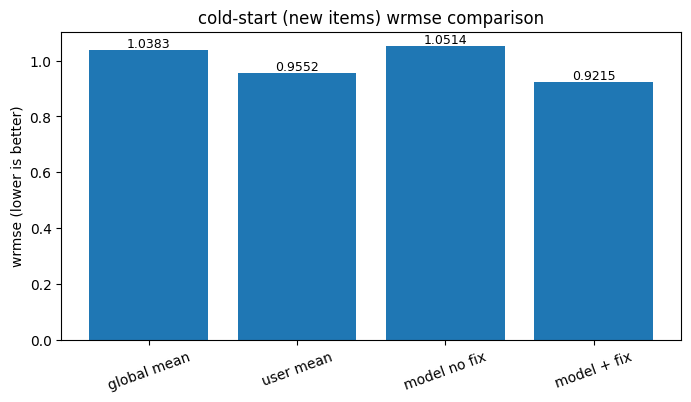

In [ ]:
# -------------------------------------------------------
# cold start strategy (cs-3): baselines vs proposed + plot
# -------------------------------------------------------

# extract cold-test labels
CS_y = CS_cold_test_df["rating"].astype("float32").to_numpy()

# map cold-test movies to indices to fetch wrmse weights
CS_cold_movie_idx = CS_cold_test_df["movie_id"].map(lambda x: movie2idx.get(int(x), 0)).astype("int32").to_numpy()

# build cold-test weights from the same global movie weight array used in training
CS_w = movie_weight_arr[CS_cold_movie_idx].astype(np.float32)

# baseline 1: global mean from explicit training
CS_global_mean = float(CS_train_explicit_df["rating"].mean())

# predict global mean for all cold-test rows
CS_pred_global = np.full((len(CS_cold_test_df),), CS_global_mean, dtype=np.float32)

# compute wrmse for global mean baseline
CS_wrmse_global = CS_wrmse(CS_pred_global, CS_y, CS_w)

# baseline 2 (optional, stronger): user mean from explicit training with fallback to global mean
CS_user_mean = CS_train_explicit_df.groupby("user_id")["rating"].mean()

# compute user-mean predictions for cold-test users
CS_pred_usermean = CS_cold_test_df["user_id"].map(CS_user_mean).fillna(CS_global_mean).astype("float32").to_numpy()

# compute wrmse for user-mean baseline
CS_wrmse_usermean = CS_wrmse(CS_pred_usermean, CS_y, CS_w)

# compute model results from the final trained CS_rating_model
CS_wrmse_model_no_fix = CS_eval_cold_wrmse(CS_rating_model, use_cold_fix=False)
CS_wrmse_model_fix = CS_eval_cold_wrmse(CS_rating_model, use_cold_fix=True)

# print final comparison table
print("\ncs cold-item evaluation (lower is better):")
print(f"baseline global mean wrmse:     {CS_wrmse_global:.5f}")
print(f"baseline user mean wrmse:       {CS_wrmse_usermean:.5f}")
print(f"model no fix (bad cold items):  {CS_wrmse_model_no_fix:.5f}")
print(f"model + proposed fix:           {CS_wrmse_model_fix:.5f}")

# plot a small bar chart for the report
CS_labels = ["global mean", "user mean", "model no fix", "model + fix"]
CS_vals = [CS_wrmse_global, CS_wrmse_usermean, CS_wrmse_model_no_fix, CS_wrmse_model_fix]

# create figure
plt.figure(figsize=(8, 4))

# draw bars
plt.bar(CS_labels, CS_vals)

# set title
plt.title("cold-start (new items) wrmse comparison")

# set y label
plt.ylabel("wrmse (lower is better)")

# rotate x labels for readability
plt.xticks(rotation=20)

# add value labels
for i, v in enumerate(CS_vals):
    plt.text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

# show
plt.show()


## Results & Conclusions:
In our cold-item simulation, we removed all interactions of a set of moderately popular movies from training and evaluated on their held-out explicit ratings using WRMSE (the competition metric). A naive global-mean baseline achieved WRMSE = 1.0383, and a stronger baseline that predicts each user’s mean rating (with global-mean fallback) achieved WRMSE = 0.9552. When using the recommender without an explicit cold-start strategy, performance degraded to WRMSE = 1.0514, because unseen items receive untrained (effectively random) item-id embeddings. In contrast, our proposed cold-item strategy is mapping unseen items to a shared UNK item embedding (index 0) whose embedding/bias are set to the mean of trained items, while still using available content tokens reduced error substantially to WRMSE = 0.9215, outperforming both baselines. This demonstrates that the explicit cold-item handling prevents failure on unseen items and provides a meaningful improvement beyond naive priors.

#### Regarding Cold Users:
For cold users (users not observed during training), personalization is not possible due to the lack of historical interactions and metadata. We handle this by mapping unseen users to a shared UNK user embedding (index 0) whose embedding/bias are set to the mean of trained users, causing predictions to rely primarily on global priors and item/content signals. Offline evaluation in this section focused on cold items; in our split, only a small number of cold-test users were unseen in explicit training, so the measured gains mainly reflect improved cold-item robustness.